# Context
Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.



# Objective:
In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having a higher chance of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You, as a data scientist at EasyVisa, have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals. Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

# Data Description:

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

**case_id:** ID of each visa application

**continent**: Information of continent the employee

e**ducation_of_employee**: Information of education of the employee

**has_job_experience**: Does the employee have any job experience? Y= Yes; N = No

**requires_job_training**: Does the employee require any job training? Y = Yes; N = No

**no_of_employees**: Number of employees in the employer's company

**yr_of_estab**: Year in which the employer's company was established

r**egion_of_employment**: Information of foreign worker's intended region of employment in the US.

**prevailing_wage:** Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.

**unit_of_wage**: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.

**full_time_position**: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position

**case_status**: Flag indicating if the Visa was certified or denied

In [ ]:
#let colab access my google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import the libraries

In [ ]:
import os

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics
# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)



# Load the dataset

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/project python 5/EasyVisa.csv')

In [ ]:
# copying data to another variable to avoid any changes to original data
data= df.copy()


# Overview of the Dataset



# View the first five rows of dataset

In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


# View the last five rows of dataset

In [ ]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


# Check the shape of dataset

In [ ]:
data.shape

(25480, 12)

Observation:The dataset has 25480 rows and 12 columns.

# **Checking for Duplicate values**

In [ ]:
data.duplicated().sum()

np.int64(0)

There are no duplicate value in dataset.

# **Checking for Missing Values**

In [ ]:
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


There are no missing value in dataset.



# Check the data types of the columns for the dataset¶

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


# Insights

There are no null values in the dataset. All columns except Number of employees, year of establishment and prevailing wage are object data types.

In [ ]:
# Looking at columns of object type
cols = data.select_dtypes(['object'])
cols.columns


Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [ ]:
# Converting from object to category
for i in cols.columns:
    df[i] = df[i].astype('category')

In [ ]:
# Checking that the change was done correctly
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   case_id                25480 non-null  category
 1   continent              25480 non-null  category
 2   education_of_employee  25480 non-null  category
 3   has_job_experience     25480 non-null  category
 4   requires_job_training  25480 non-null  category
 5   no_of_employees        25480 non-null  int64   
 6   yr_of_estab            25480 non-null  int64   
 7   region_of_employment   25480 non-null  category
 8   prevailing_wage        25480 non-null  float64 
 9   unit_of_wage           25480 non-null  category
 10  full_time_position     25480 non-null  category
 11  case_status            25480 non-null  category
dtypes: category(9), float64(1), int64(2)
memory usage: 2.0 MB


In [ ]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)#using only object data types

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

# Checking the statistical summary of all columns

In [ ]:
# Looking at the statistical summary of all variables
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.000,NaN,NaN,NaN,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,NaN,NaN,NaN,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.000,NaN,NaN,NaN,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Observations:
The case_id column is unique for each row, as expected.

The most frequent continent is Asia.

The most frequent education level is Bachelor's.

More employees have job experience than not.

Most employees do not require job training.

The average number of employees is around 5667.

The average year of establishment is around 1979.

The most frequent region of employment is Northeast.

The average prevailing wage is around 74455.

The most frequent unit of wage is Year.

Most positions are full-time.
More cases are certified than denied.

There are negative values in the column no_of_employees which require appropriate treatment or investigation to ensure data accuracy.

The column year of establishment appears to have a resonable range, with compnaies established as early as 1800 and to as recently as 2016.

The prevailing wage column seems to have skewed distribution as the minimum wage is 2 dollars and maximum wage is 319,210 dollars. This suggests that there might be outliers, or the disparity may be due to difference in unit of wages.




In [ ]:
#Dropping case_id column because it is not significant for training the model
data.drop(["case_id"], axis=1, inplace=True)

In [ ]:
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


# Q-1 Exploratory Data Analysis (EDA)

In [ ]:
# Function to plot boxplot and histogram

def histogram_boxplot(data, feature, figsize=(15, 10), kde=True, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )
    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

# Univariate Analysis

# Observation on Continent:

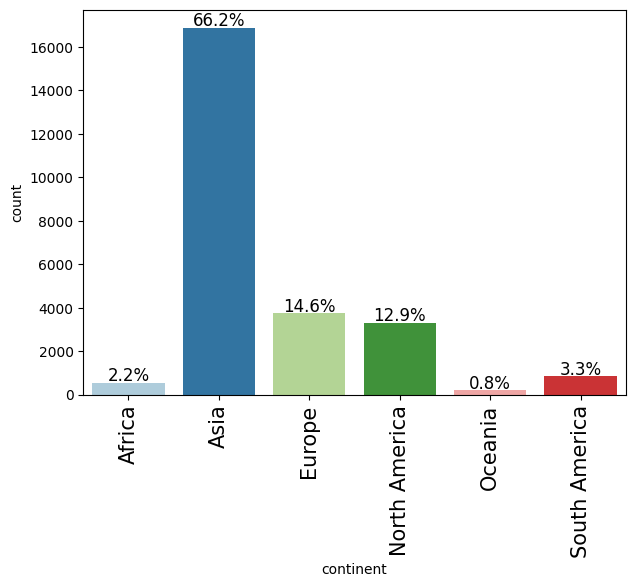

In [ ]:
labeled_barplot(data, "continent", perc=True)

Observations:
The majority of the applications are from Asia (66.2%).

Europe and North America have a moderate number of applications (14.6% and 12.9% respectively).

South America, Africa, and Oceania have significantly fewer applications (3.3%, 2.2%, and 0.8% respectively).

# 2. Observations on education of employee

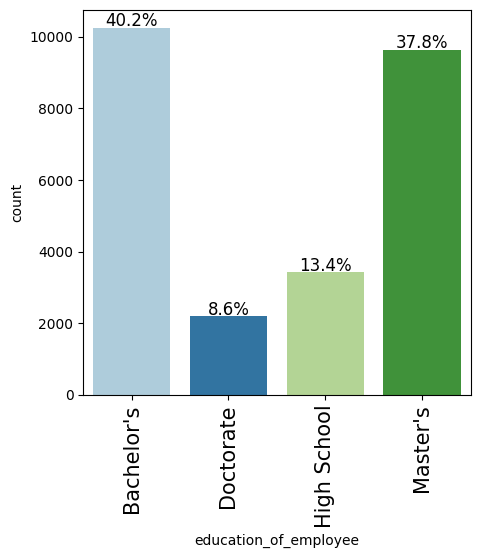

In [ ]:
labeled_barplot(data, "education_of_employee", perc=True)

Observations:
:Bachelor's degree holders account for the largest proportion of applications (40.2%). :Master's degree holders are also a significant group (37.8%).

:High school graduates represent a smaller portion (13.4%).

:Doctorate holders have the lowest number of applications (8.6%).

# 3. Observations on job experience



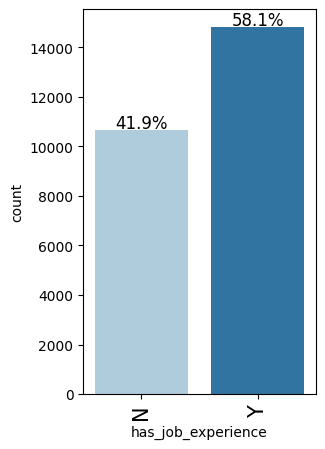

In [ ]:
labeled_barplot(data, "has_job_experience", perc=True)

# Observations:
A larger percentage of employees (58.1%) have job experience.

Conversely, 41.9% of employees do not have job experience.

# 4. Observations on on job training

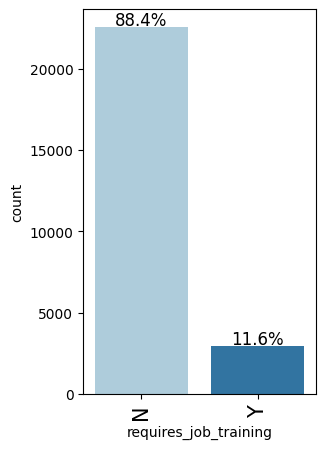

In [ ]:
labeled_barplot(data, "requires_job_training", perc=True)


# Observations:

 A large majority of employees (88.4%) do not require job training.

Only 11.6% of employees require job training.

# 5. Observations on number of employees

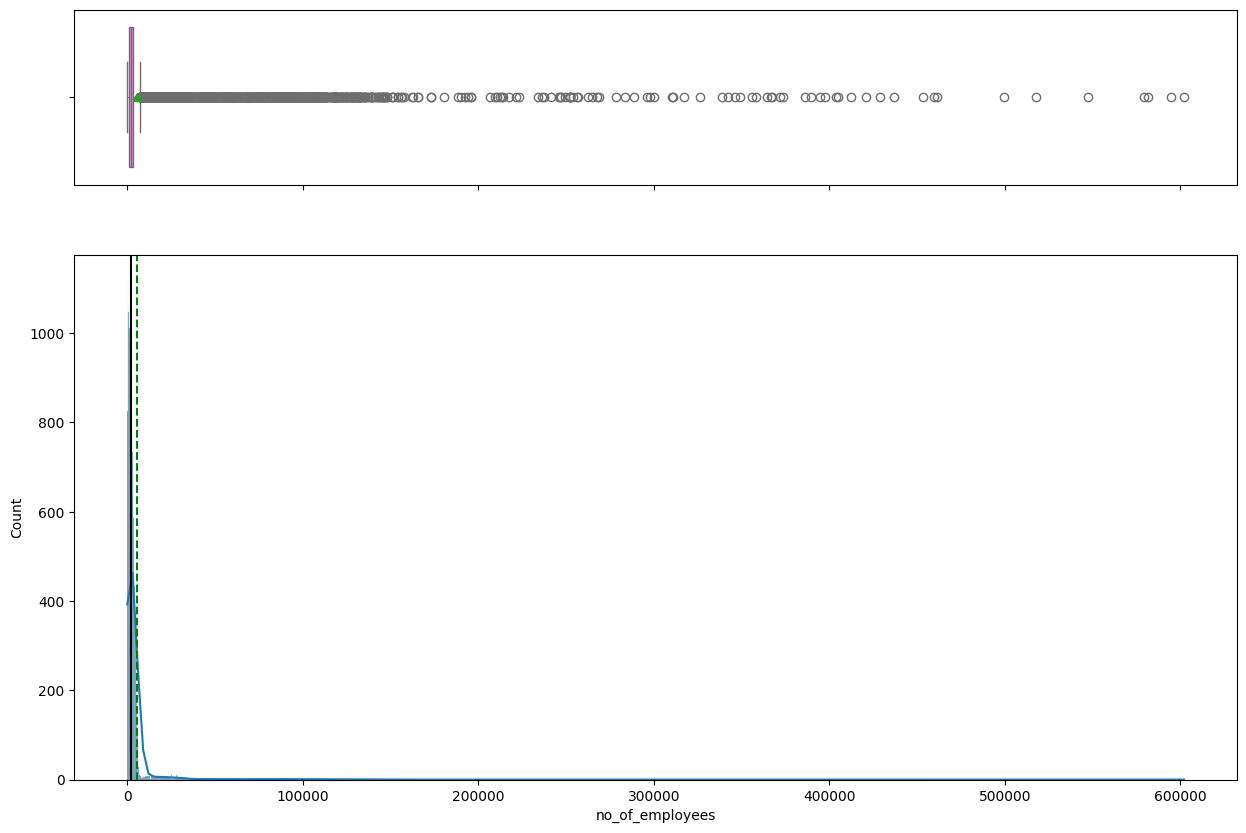

In [ ]:
# Visual for number of employees
histogram_boxplot(data, 'no_of_employees')

We know that there were negative values in this column. It is not possible for a company to have negative employees. We will treat them even if they don't appear as outliers.

We will first check how many companies have negative values in this column.

In [ ]:
# Looking at cases with negative values in number of employees
data.loc[df['no_of_employees']<=0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,Europe,Master's,N,N,-25,1980,Northeast,39452.990,Year,Y,Certified
378,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.140,Year,Y,Denied
832,South America,Master's,Y,N,-17,2002,South,129701.940,Year,Y,Certified
2918,Asia,Master's,Y,N,-26,2005,Midwest,112799.460,Year,Y,Certified
6439,Asia,Bachelor's,N,N,-14,2013,South,103.970,Hour,Y,Denied
6634,Asia,Bachelor's,Y,N,-26,1923,West,5247.320,Year,Y,Denied
7224,Europe,Doctorate,N,N,-25,1998,Midwest,141435.950,Year,Y,Certified
7281,Asia,High School,N,N,-14,2000,Midwest,58488.500,Year,Y,Denied
7318,Asia,Bachelor's,Y,Y,-26,2006,South,115005.610,Year,Y,Certified
7761,Asia,Master's,N,N,-11,2009,Midwest,38457.510,Year,Y,Certified


Many rows have negative values in the number of employees column. They could be typos, we can replace them for their positive values (the absolute value).

In [ ]:
# Changing the negative values for positive in number of employees
data['no_of_employees'] = abs(data['no_of_employees'])

In [ ]:
# Checking the change was done
data.loc[df['no_of_employees']<=0]

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,Europe,Master's,N,N,25,1980,Northeast,39452.990,Year,Y,Certified
378,Asia,Bachelor's,N,Y,11,2011,Northeast,32506.140,Year,Y,Denied
832,South America,Master's,Y,N,17,2002,South,129701.940,Year,Y,Certified
2918,Asia,Master's,Y,N,26,2005,Midwest,112799.460,Year,Y,Certified
6439,Asia,Bachelor's,N,N,14,2013,South,103.970,Hour,Y,Denied
6634,Asia,Bachelor's,Y,N,26,1923,West,5247.320,Year,Y,Denied
7224,Europe,Doctorate,N,N,25,1998,Midwest,141435.950,Year,Y,Certified
7281,Asia,High School,N,N,14,2000,Midwest,58488.500,Year,Y,Denied
7318,Asia,Bachelor's,Y,Y,26,2006,South,115005.610,Year,Y,Certified
7761,Asia,Master's,N,N,11,2009,Midwest,38457.510,Year,Y,Certified


All the negative values in the number of employees column has been changed to their absolute value.



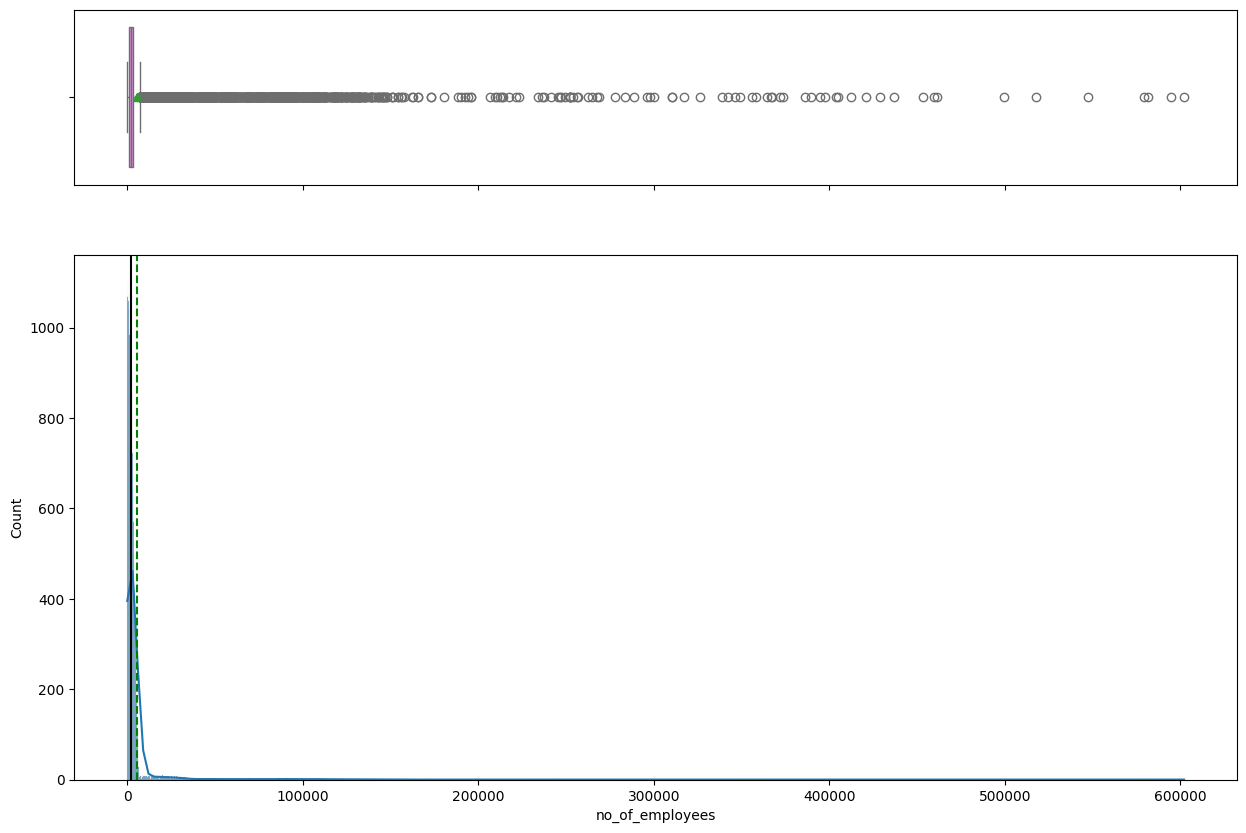

In [ ]:
#Checking if there are changes in the visuals
histogram_boxplot(data, 'no_of_employees')

Observation:

The distribution is highly skewed to the right, indicating that most companies have a smaller number of employees, with a few companies having a very large number of employees (outliers).

The boxplot clearly shows the presence of many outliers, which are companies with a significantly higher number of employees than the majority.

The mean (green dashed line) is much higher than the median (black solid line), which is another indicator of the right skewness and the influence of outliers.

```

```



# Observation on year of establishment:


<Axes: xlabel='yr_of_estab', ylabel='Count'>

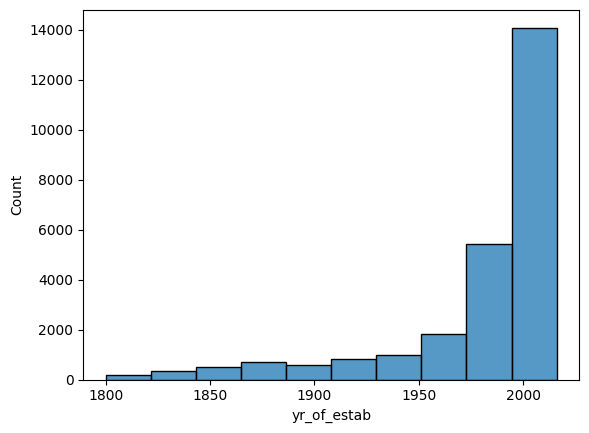

In [ ]:
sns.histplot(data['yr_of_estab'], bins=10)

# Observation:
The distribution is heavily skewed towards recent years, indicating that most companies in the dataset were established more recently.

There's a noticeable increase in the number of companies established from the late 20th century onwards, with a large peak in the 2000s.

There are fewer companies established in the earlier years shown in the histogram (1800s to mid-1900s

# . Observations on region of employment

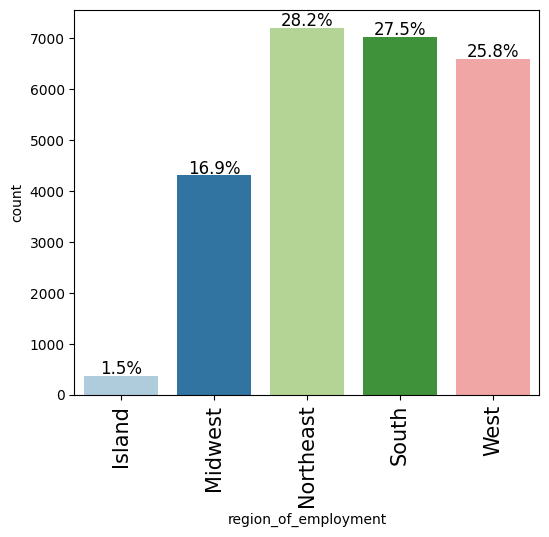

In [ ]:
labeled_barplot(data, "region_of_employment", perc=True)

# Observation on region of employment:

The Northeast region has the highest number of applications (28.2%).

The South and West regions also have a significant number of applications (27.5% and 25.8% respectively).

The Midwest region has a moderate number of applications (16.9%).

The Island region has the lowest number of applications (1.5%)



# Observations on prevailing wage

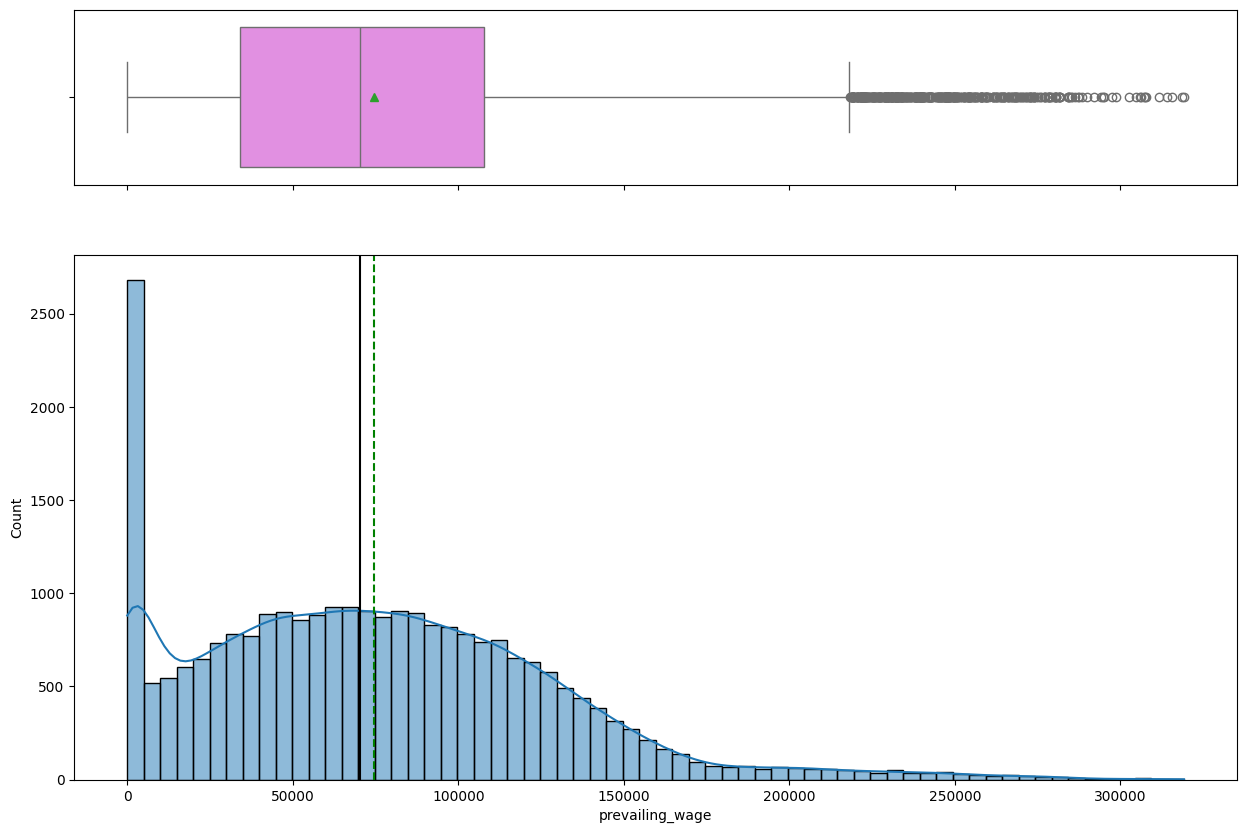

In [ ]:
histogram_boxplot(data,'prevailing_wage')

# Observations :
The distribution is highly skewed to the right, indicating that most companies have a smaller number of employees, with a few companies having a very large number of employees (outliers).

The boxplot clearly shows the presence of many outliers, which are companies with a significantly higher number of employees than the majority.

The mean (green dashed line) is much higher than the median (black solid line), which is another indicator of the right skewness and the influence of outliers.

There are applicants whose wage is around 0 and there are alot of them, we might need to check this.


[ ]


In [ ]:
data.loc[data['prevailing_wage'] < 100, 'unit_of_wage'].value_counts()

,count
unit_of_wage,
Hour,176


It looks like the small wages are actually hourly based.



# Observations on unit of wage

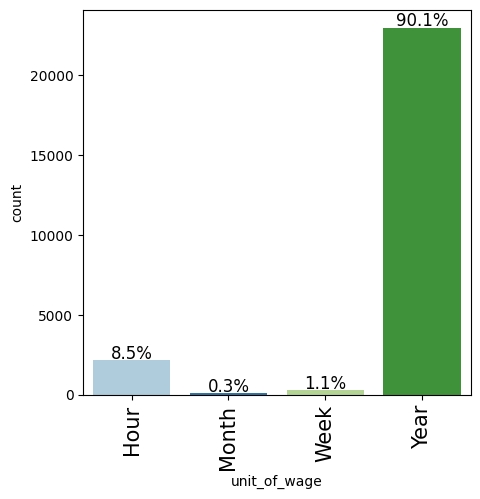

In [ ]:
labeled_barplot(data, "unit_of_wage", perc=True)

# Observation:
The vast majority of wages are paid on a yearly basis (90.1%).

Hourly wages are the second most common (8.5%).

Weekly and monthly wages are much less frequent (1.1% and 0.3% respectively).

# Observations on type of position

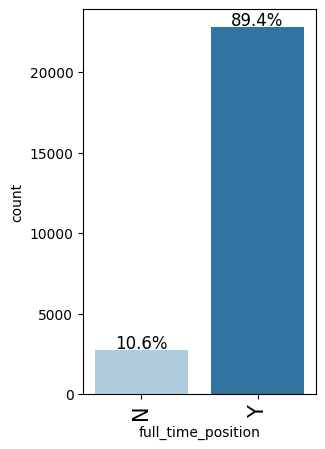

In [ ]:
labeled_barplot(data, "full_time_position", perc=True)

# Observations:
A large majority of positions are full-time (89.4%).

Only 10.6% of positions are not full-time.

# 11. Observations on case status

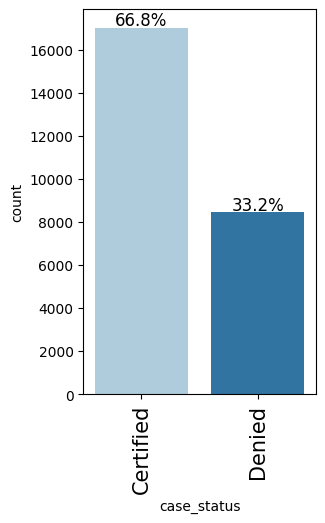

In [ ]:
labeled_barplot(data, "case_status", perc=True)

**Observations**:
Based on the data, the 66.8% of the applications were certified, while 33.2% were denied.

# Bivariate Analysis

# Heatmap:

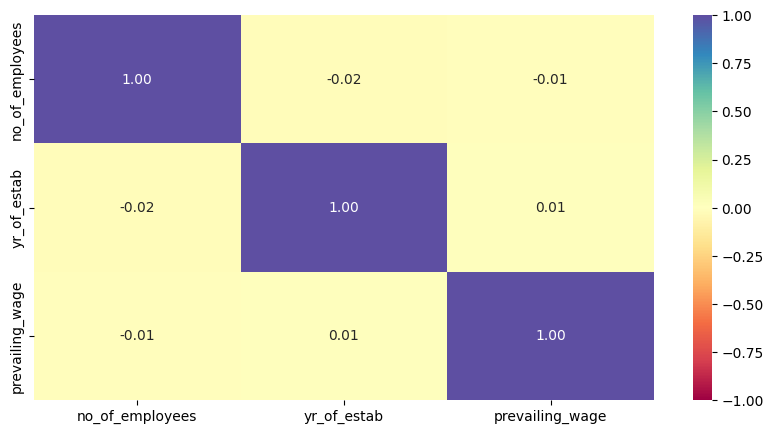

In [ ]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

# Observations:
There is very low correlation between no_of_employees, yr_of_estab, and prevailing_wage.

The correlation coefficients are all close to zero, indicating that changes in one of these variables do not strongly predict changes in the others.



# Pairplot

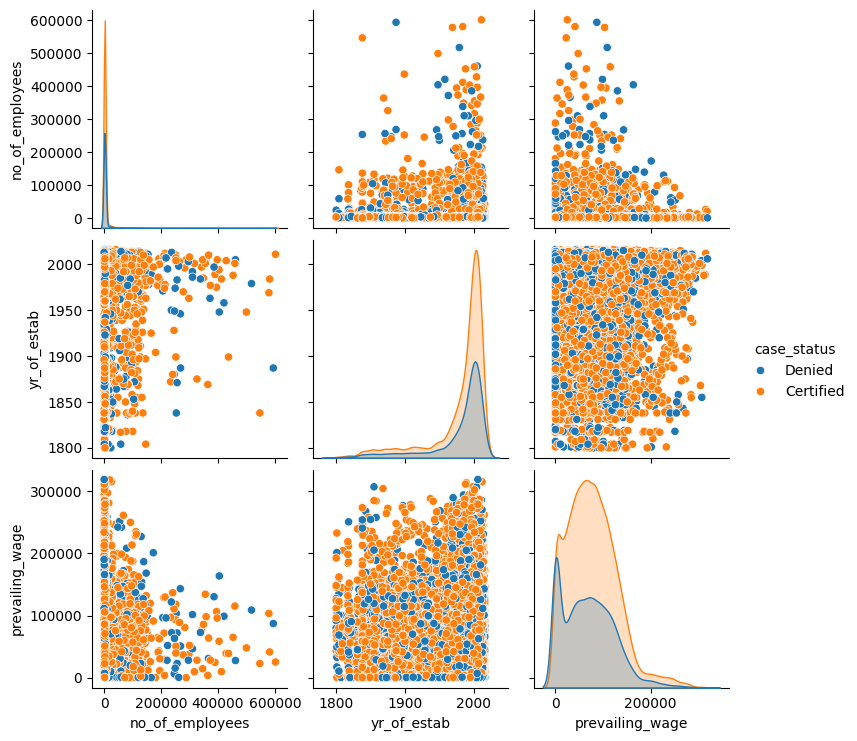

In [ ]:
sns.pairplot(data,hue='case_status')

Observations:

There doesn't appear to be a clear linear separation between 'Certified' and 'Denied' cases based on any single numerical variable (no_of_employees, yr_of_estab, or prevailing_wage).

For no_of_employees and prevailing_wage, the points for 'Certified' and 'Denied' are largely mixed, especially at lower values.

For yr_of_estab, both 'Certified' and 'Denied' cases are present across the range of years, although there might be some subtle differences in density in certain periods.

The diagonal plots show the distribution of each numerical variable for both 'Certified' and 'Denied' cases. This reinforces the observation that the distributions for the two case statuses overlap significantly for these variables.



# Creating functions that will help us with further analysis.

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )
    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )
    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5), color=['green', 'orange'])
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

# 1. Case Status vs Education:
Those with higher education may want to travel abroad for a well-paid job. Let's find out if education has any impact on visa certification.





case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


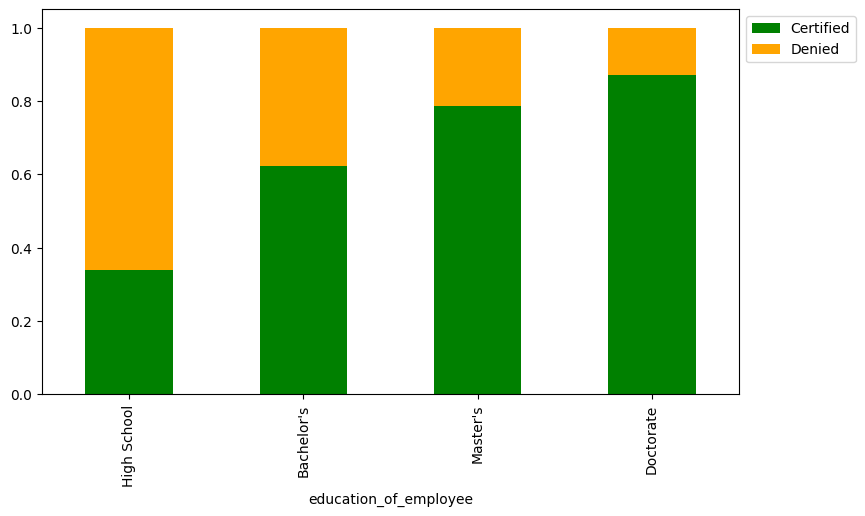

In [ ]:
stacked_barplot(data, "education_of_employee", "case_status")

# Observations:

Applicants with a Doctorate degree have the highest certification rate, followed by Master's degree holders.

High School graduates have the lowest certification rate, with a higher proportion of denied cases compared to other education levels.

Bachelor's degree holders have a certification rate between those with High School and Master's degrees.

This suggests that higher education levels are associated with a higher likelihood of visa certification.



# 2. Case Status vs Continent
Lets' similarly check for the continents and find out how the visa status vary across different continents.

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


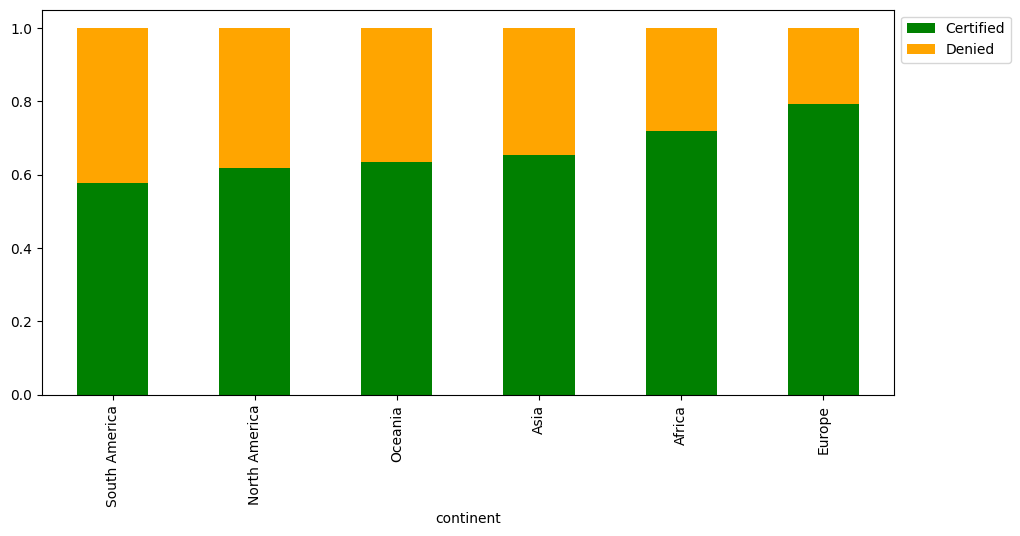

In [ ]:
stacked_barplot(data, "continent", "case_status")

# Observations:

Europe has the highest certification rate among all continents.

Asia and Africa have similar certification rates, which are lower than Europe and but higher than North and South America.

South America has the lowest certification rate.

North America has the second lowest certification rate.



# Case Status vs Job Experience:
Experienced professionals might look abroad for opportunities to improve their lifestyles and career development.

Let's see if having work experience has any influence over visa certification

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


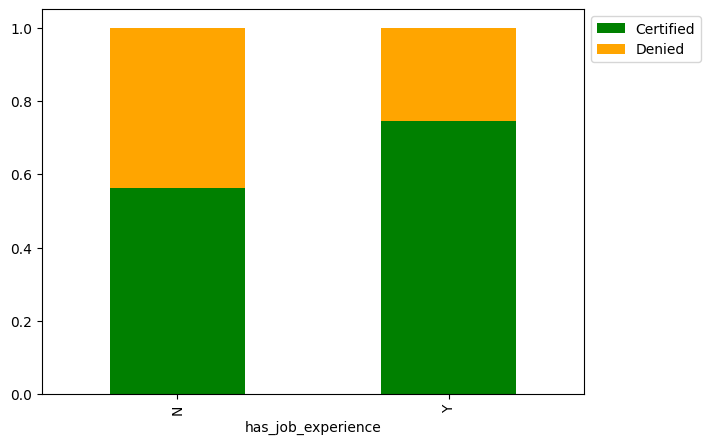

In [ ]:
stacked_barplot(data, "has_job_experience", "case_status")

# Observations:
Employees with job experience ('Y') have a higher certification rate compared to those without job experience ('N').

This indicates that having job experience is associated with a higher likelihood of visa certification.

# Case Status vs Job Training

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


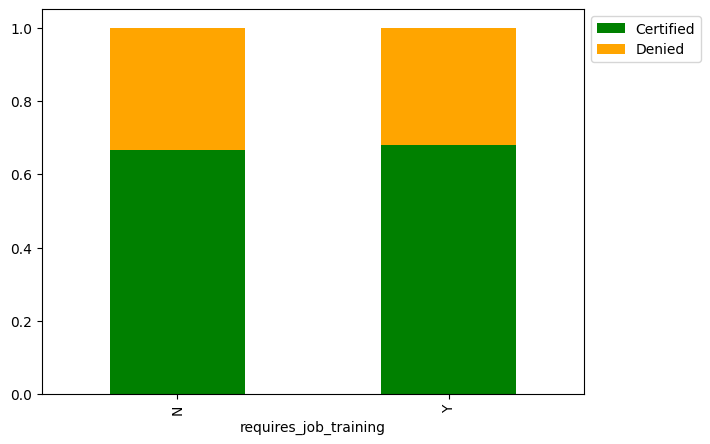

In [ ]:
stacked_barplot(data, "requires_job_training", "case_status")

# Observation
Based on the stacked bar plot showing the relationship between case status and whether job training is required:

There isn't a significant difference in the certification rate between those who require job training ('Y') and those who do not ('N')

. This suggests that requiring job training does not have a strong impact on the likelihood of visa certification.



# Case Status vs region of Employment

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


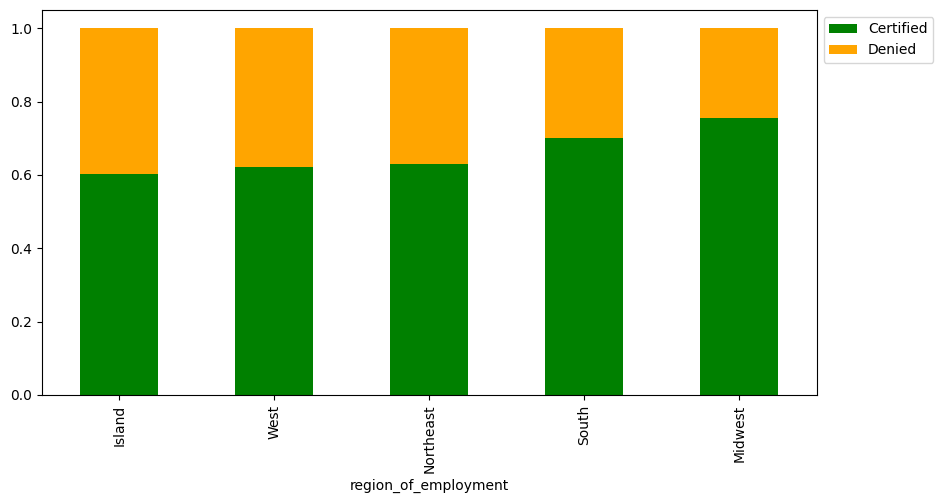

In [ ]:
stacked_barplot(data, "region_of_employment", "case_status")

# Observation:

The Midwest region has the highest certification rate.

The South and Northeast regions have similar certification rates, which are lower than the Midwest but higher than the West and Island regions.

The West region has a lower certification rate compared to the Midwest, South, and Northeast.

The Island region has the lowest certification rate, with the highest proportion of denied cases.

# Case Status vs type of position

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


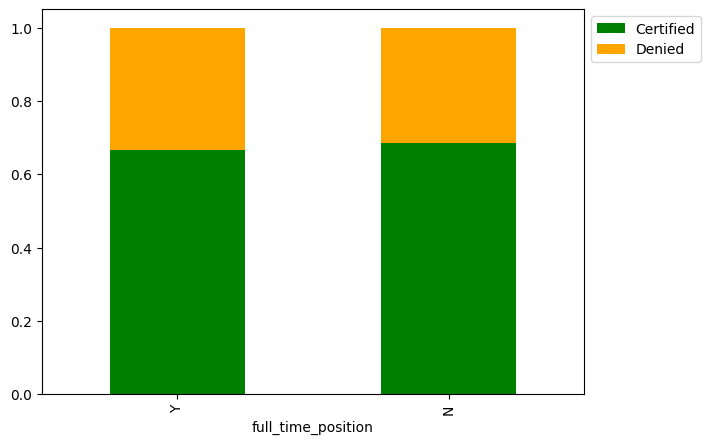

In [ ]:
stacked_barplot(data, "full_time_position", "case_status")

# Observation:
Looking at the proportion of 'Certified' cases within each category, it appears that non-full-time positions ('N') have a slightly higher certification rate than full-time positions ('Y').

# Case Status vs Unit of wage

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


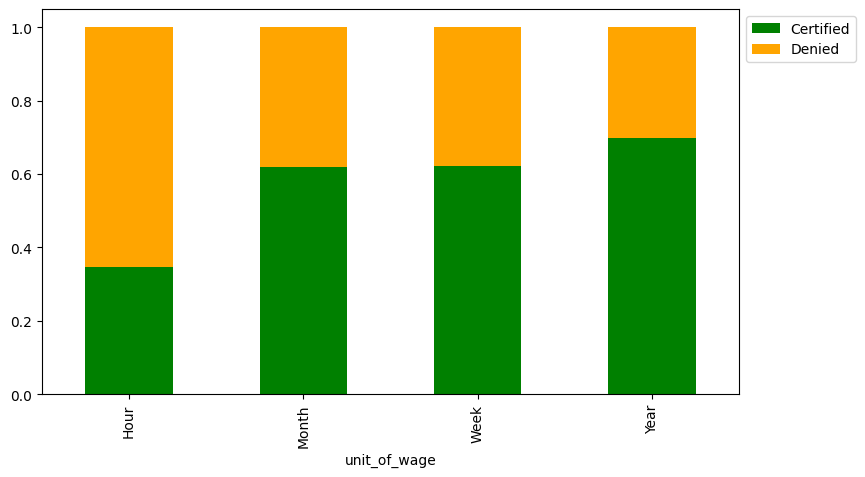

In [ ]:
stacked_barplot(data, "unit_of_wage", "case_status")

# Observations:
The vast majority of wages are paid on a yearly basis (90.1%), and these have the highest certification rate.

Hourly wages are the second most common (8.5%) and have a lower certification rate than yearly wages, with a higher proportion of denied cases.

Weekly and monthly wages are much less frequent (1.1% and 0.3% respectively), and their certification rates appear to be somewhere between yearly and hourly wages.

# Prevailing wages vs Case Status:
The US government has established a prevailing wage to protect local talent and foreign workers. Let's analyze the data and see if the visa status changes with the prevailing wage¶

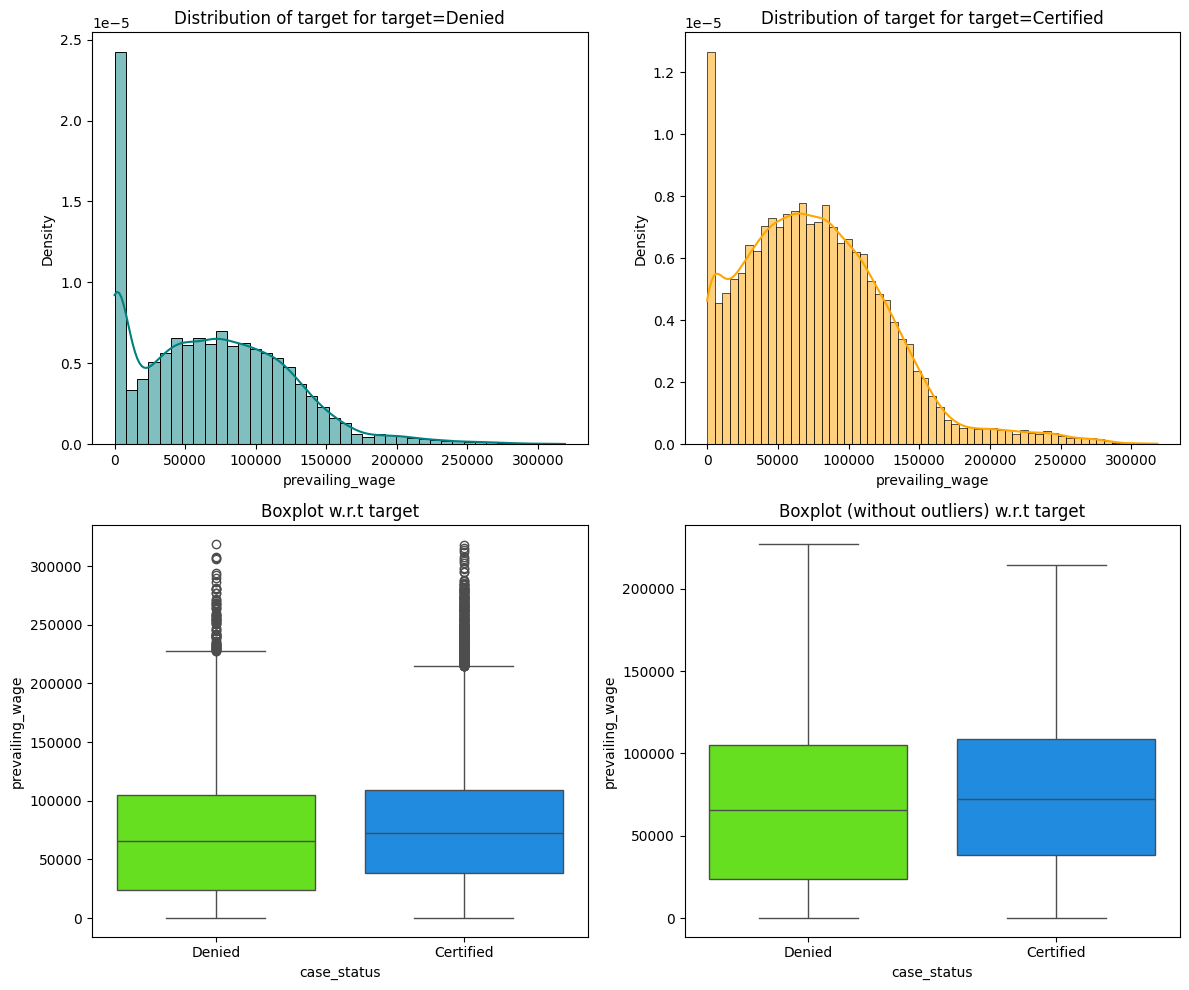

In [ ]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

# Observation:

The distribution of prevailing wage is highly skewed to the right for both 'Denied' and 'Certified' cases, indicating that most applications have lower prevailing wages.

The boxplots show that the median prevailing wage for 'Certified' cases is slightly higher than for 'Denied' cases.

There are outliers in both groups, representing applications with very high prevailing wages.

When outliers are excluded, the boxplot still shows a slightly higher median prevailing wage for 'Certified' cases.

This suggests that a higher prevailing wage might be associated with a higher likelihood of visa certification, although there is significant overlap in the distributions.

# Barplot of Prevailing wage with respect to case status

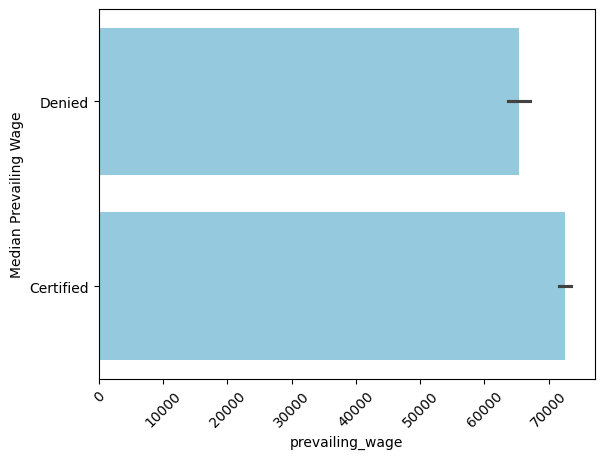

In [ ]:
#Using barplot to understand median value of prevailing wage with respect to case status
sns.barplot(x="prevailing_wage", y='case_status', data=data, estimator=np.median, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Median Prevailing Wage")
plt.show()

# Observation:
The distribution plot and boxplot indicate that the median prevailing wage is slightly higher for the cases that are certified, as compared to the cases that are denied.

The barplot indicates that the median prevailing wage for applicants whose visa is certified is approximately 72000 dollars, whereas those with denied visas is around 65000 dollars.

# Prevailing wages vs Region:
Checking if the prevailing wage is similar across all the regions of the US¶

<Axes: xlabel='region_of_employment', ylabel='prevailing_wage'>

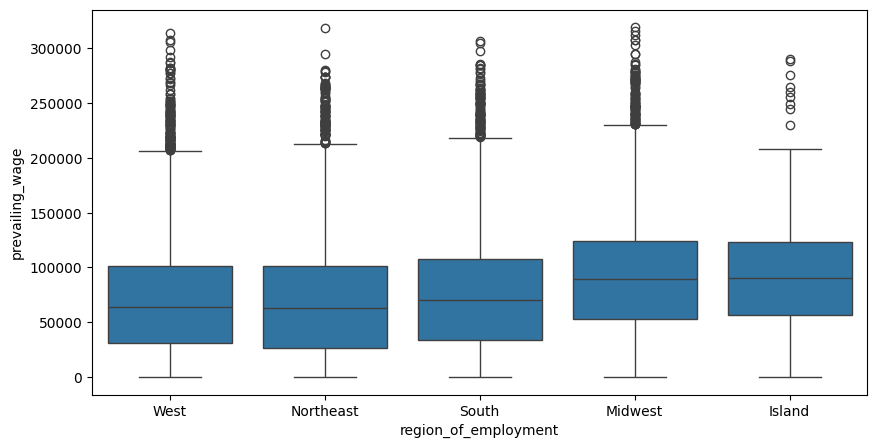

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage")

# Observations:

The median prevailing wage appears to be highest in the Midwest and Island regions, and lowest in the West and Northeast regions.

All regions show a significant number of outliers with very high prevailing wages, indicating a wide range of salaries within each region.

The spread of prevailing wages (indicated by the interquartile range, the height of the box) seems to be similar across most regions, with perhaps slightly larger spreads in the Midwest and Island regions.

Overall, while there are some differences in median prevailing wages across regions, the presence of outliers suggests that high-paying jobs exist in all regions.

# Prevailing wage and Education level
Usually education level is highly correlated to wages. Let's check if that is the case.

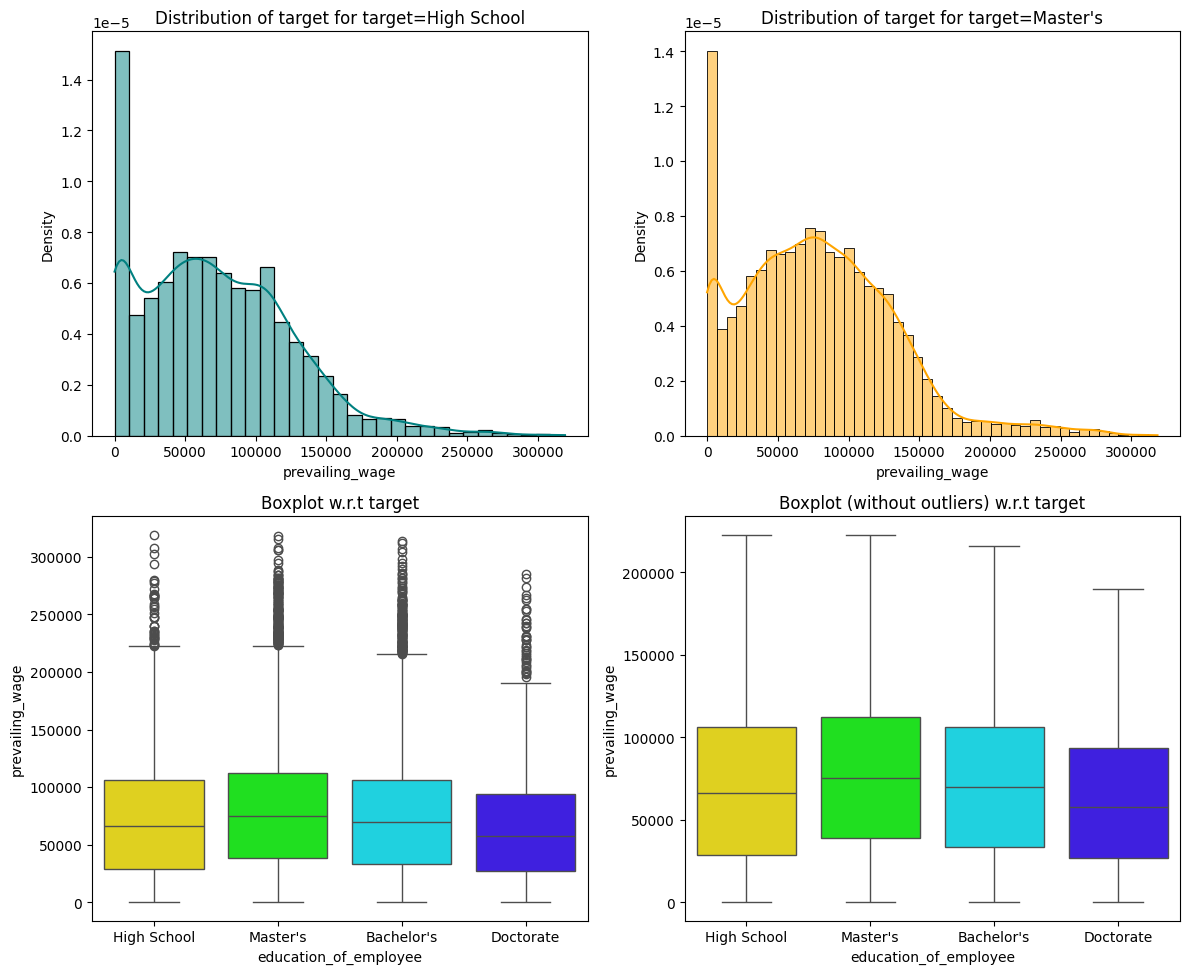

In [ ]:
# Relation between prevailing wage and education level
distribution_plot_wrt_target(data, 'prevailing_wage', 'education_of_employee')


# observation:
It is surprising that workers with a doctorate have a lower median than those with a High School degree. We will check if this is due to work experience or required job training.

Master's and Bachelor's workers have a very similar prevailing wage. Workers with a High School degree have a slightly lower prevailing wage than Master's and Bachelor's.

These dataset doesn't include certification and especialized jobs. This could influence prevailing wage for workers with a High School degree.

# Prevailing wage and Job experience

Let's check if wage is correlated to job experience

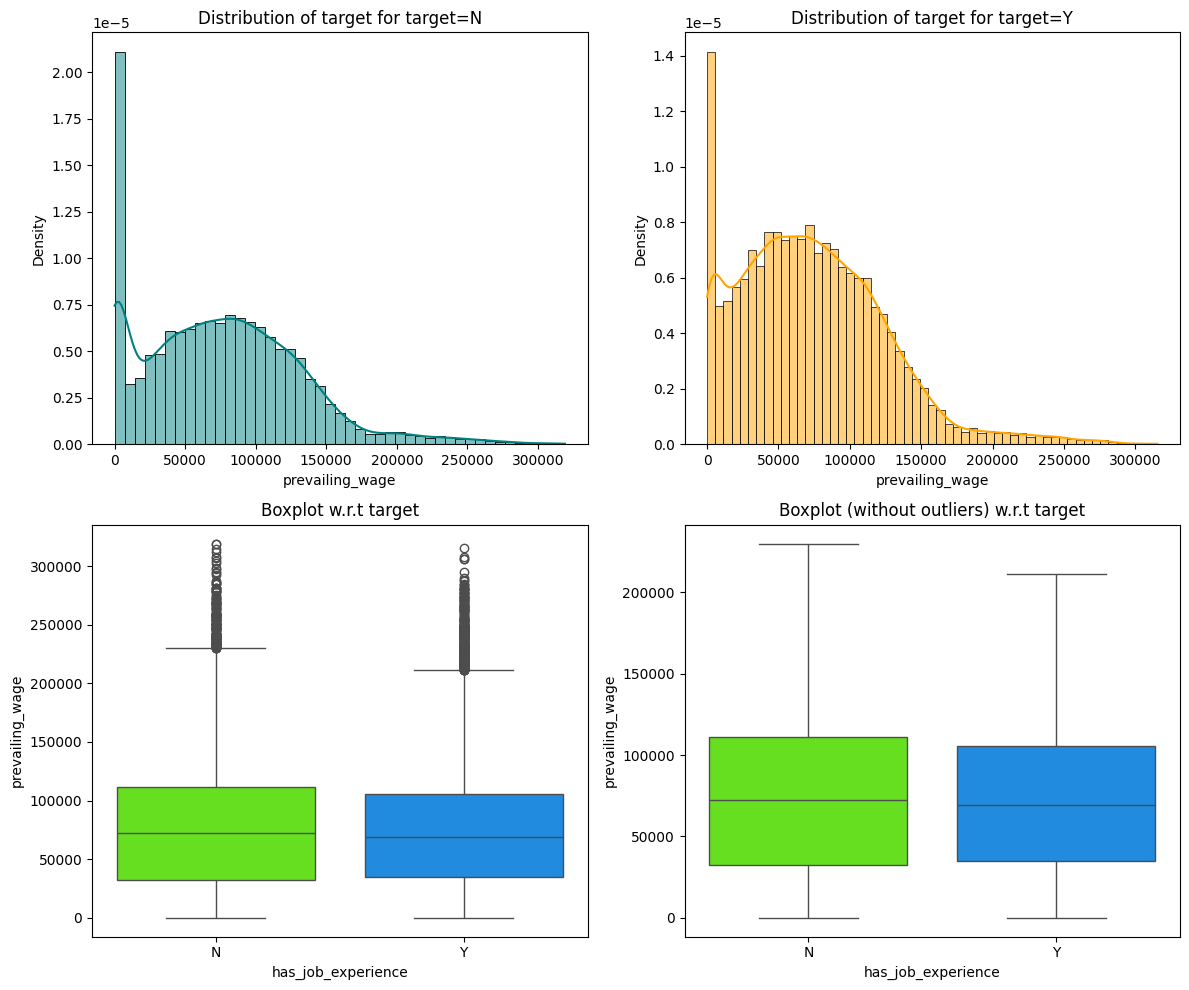

In [ ]:
# Visuals on prevailing wage and job experience
distribution_plot_wrt_target(data, 'prevailing_wage', 'has_job_experience')

# Observations:
While the median prevailing wage is slightly higher for those with job experience, the difference is not very large compared to the overall range of wages.

This indicates that while job experience might be associated with a slightly higher typical wage,



# Prevailing wage and Required job training¶


Before comparing education level with prevailing wage and experience, let's analyze the relation between wages and training


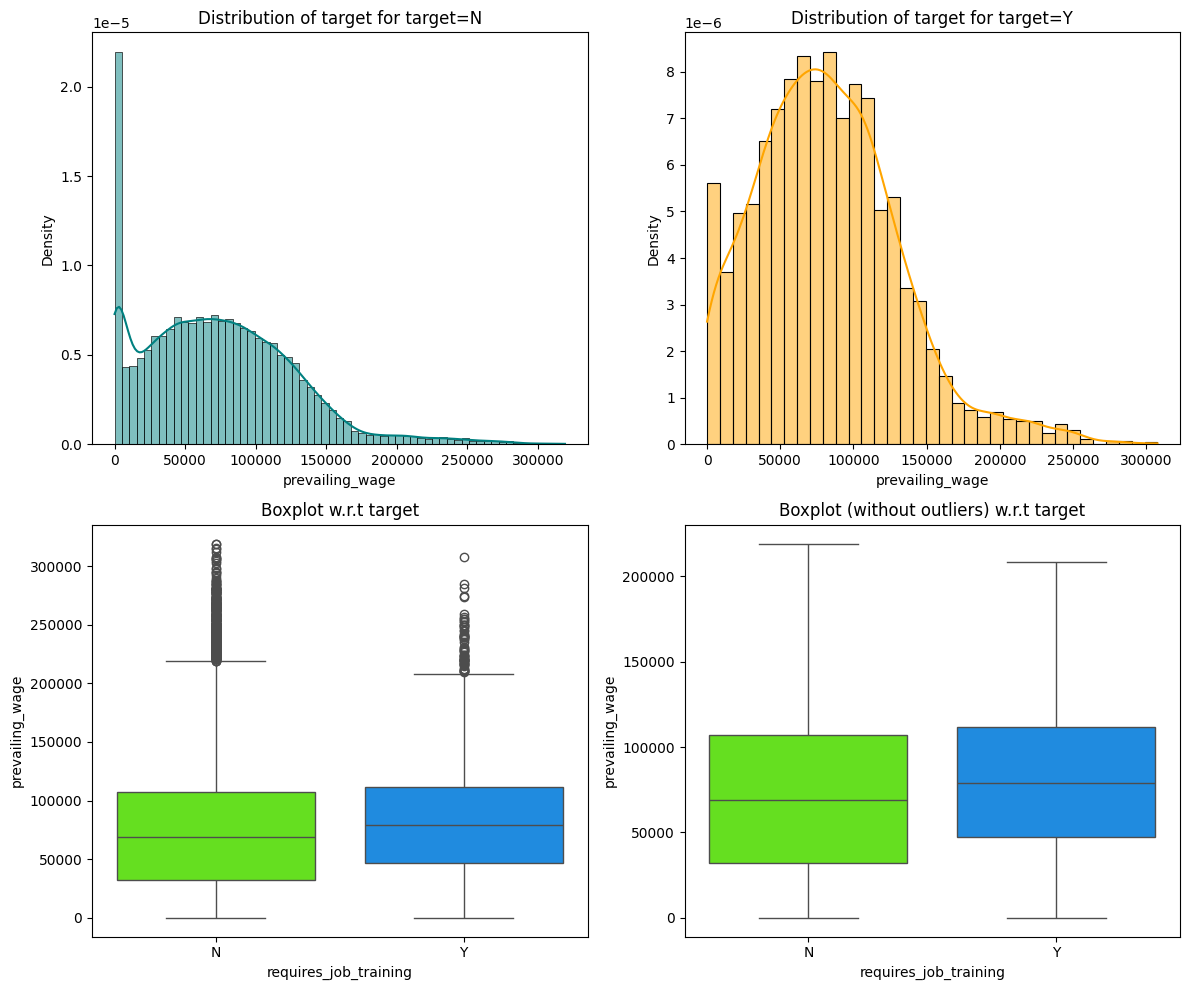

In [ ]:
# Relation between prevailing wage and job training
distribution_plot_wrt_target(data, 'prevailing_wage', 'requires_job_training')

# Observations:
Workers that require job training have a slightly higher prevailing wage median.

There are also less outliers for workers that require job training.

This makes sense as job training especializes a worker more, having a higher value for the companies.



# Prevailing wage and Unit of wage
Let's check if there is any reason for the big variation on prevailing wage.

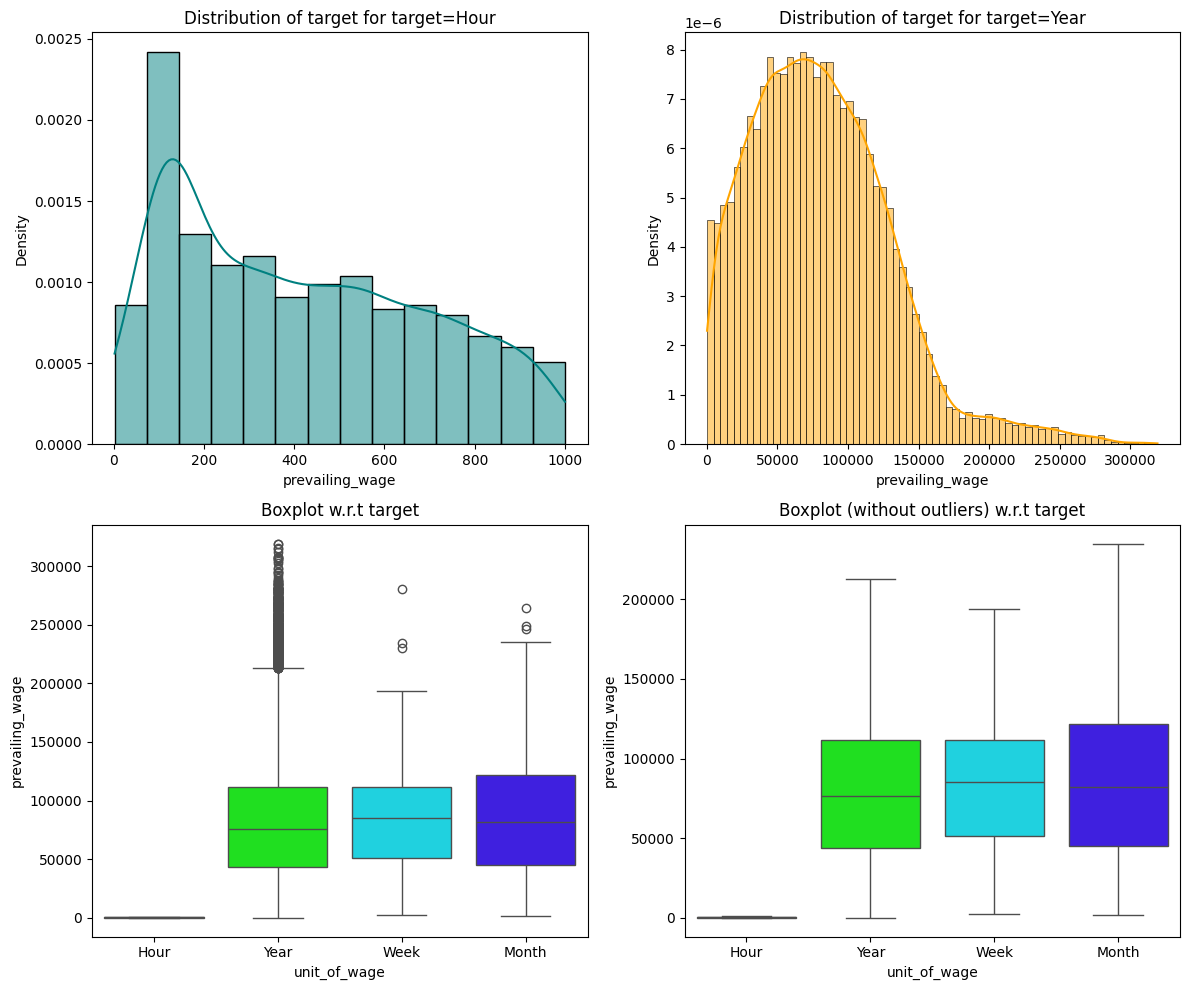

In [ ]:
# Relation between prevailing and unit of wage
distribution_plot_wrt_target(data,'prevailing_wage', 'unit_of_wage')

# Observations:
It's surprising that all units of wage are close to 0.

However, they are all above 0 which could be possible that the values are true.
After comparing prevailing wage with other variables, it doesn't seem necessary to modify the variable.

# Case status and no of employees

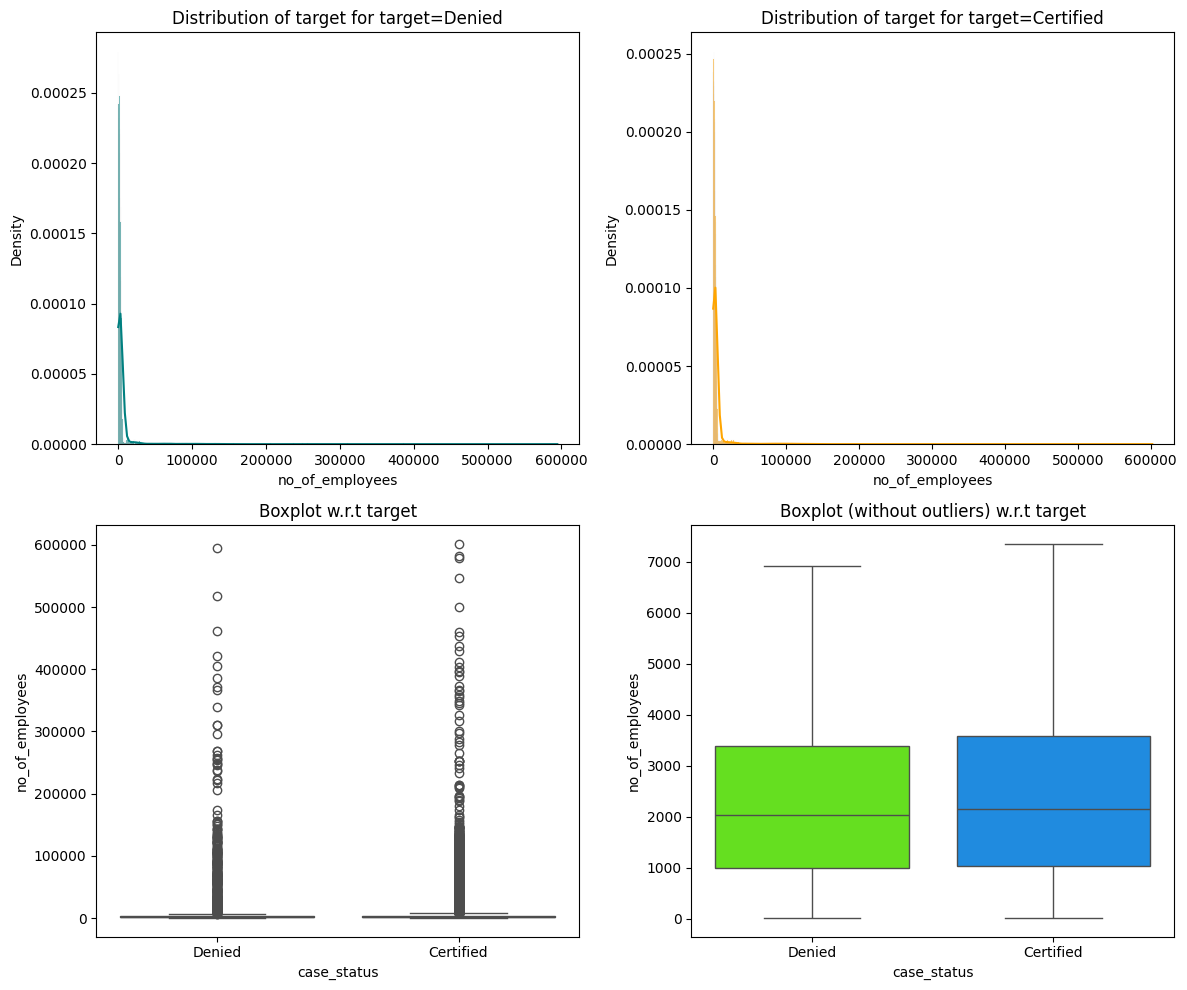

In [ ]:
# Use user-defined function distribution_plot_wrt_target() to examine case certification likelihoods across data categories
distribution_plot_wrt_target(
    data=data,
    predictor="no_of_employees",
    target="case_status"
)

# Observation:
Both the 'Denied' and 'Certified' cases show a distribution of 'no_of_employees' that is highly skewed to the right. This means that for both visa statuses, most companies have a smaller number of employees, and fewer companies have a very large number of employees.

Boxplot (with outliers): This plot clearly shows that there are many outliers in the 'no_of_employees' column for both 'Denied' and 'Certified' cases. These outliers represent companies with a significantly higher number of employees than the majority. The median number of employees appears to be similar for both certified and denied cases when considering all data points including outliers.

Boxplot (without outliers): When the outliers are excluded, the boxplot shows that the median number of employees for 'Certified' cases is slightly  higher than for 'Denied' cases. The spread of the data (interquartile range) also appears somewhat similar between the two groups, though the 'Certified' cases might have a slightly larger spread.

# Insight from Exploratory Data Analysis

Case Status Distribution: The dataset shows that approximately two-thirds of visa applications are certified, while one-third are denied.

Geographical Influence: Applications from Asia are the most numerous, and Europe has the highest visa certification rate among all continents, while South America and North America have the lowest.

Education and Job Experience Matter: Higher education levels (Master's and Doctorate) are associated with a higher likelihood of visa certification. Similarly, having job experience increases the chances of certification.

Job Training: Requiring job training does not seem to have a significant impact on the visa certification rate.

**Region of Employment: **The Midwest region shows the highest certification rate, while the Island region has the lowest.

Full-Time Position: Non-full-time positions appear to have a slightly higher certification rate than full-time positions.

Unit of Wage: The majority of wages are paid yearly, and these have the highest certification rate compared to hourly, weekly, or monthly wages.

Prevailing Wage: While the distribution of prevailing wage is skewed for both certified and denied cases, the median prevailing wage is slightly higher for certified cases.

Number of Employees: The distribution of the number of employees is also skewed, with many outliers. Companies with a slightly higher median number of employees (excluding outliers) seem to have a slightly higher chance of visa certification.

No strong correlation between numerical features: The heatmap showed very low correlation between no_of_employees, yr_of_estab, and prevailing_wage.

No clear separation in Pairplot: The pairplot of numerical features did not show clear separation between certified and denied cases based on these features alone. These insights suggest that factors like education level, job experience, continent, region of employment, and prevailing wage might be important predictors of visa case status.



# Q-2 Data Pre-processing

# Outlier Check

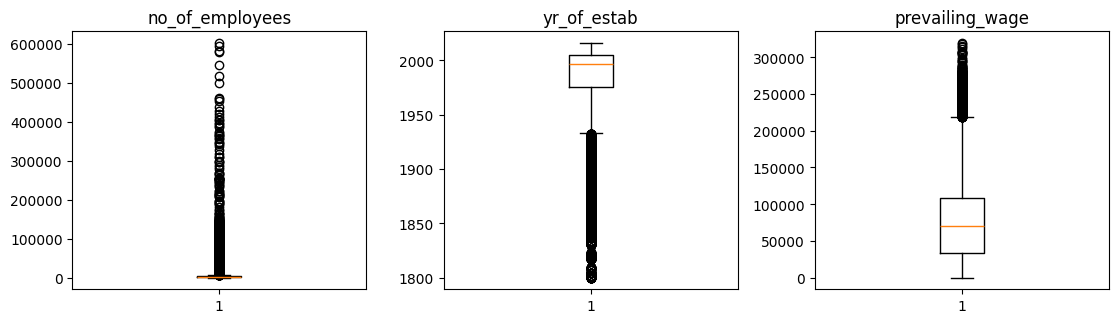

In [ ]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

# Observations:
There are outliers in all numerical columns of the dataset.

However, they will not be adjusted as they represent plausible values and reflect real-world variations.



# Missing Values:
Missing values already checked.There are no missing values in dataset.

# Feature Engineering:
1.Column 'case_id' has already been dropped.

2.Previously, we mentioned the column prevailing wage. It isn't necassary to change this variable into a yearly wage as is varies by unit of wage. We will leave that column as it is.

3Dependent variable (case_status) is of categorical type, we will change this to a binary variable.

4 We will change column year of establishment into year_since_estab.

In [ ]:
# Checking the highest year of establishment
data.yr_of_estab.max()

2016

In [ ]:
# Modifying the year of establishment to decrease the high numbers
data['yr_since_estab'] = 2017 - data['yr_of_estab']
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,yr_since_estab
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied,10
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified,15
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied,9
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied,120
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified,12


In [ ]:
#drop the column of year of establishment
data.drop('yr_of_estab',axis=1,inplace=True)
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,yr_since_estab
0,Asia,High School,N,N,14513,West,592.203,Hour,Y,Denied,10
1,Asia,Master's,Y,N,2412,Northeast,83425.650,Year,Y,Certified,15
2,Asia,Bachelor's,N,Y,44444,West,122996.860,Year,Y,Denied,9
3,Asia,Bachelor's,N,N,98,West,83434.030,Year,Y,Denied,120
4,Africa,Master's,Y,N,1082,South,149907.390,Year,Y,Certified,12


The column 'yr_of_estab' has been dropped correctly.

A new column 'yr_since_estab' was added to represent the amount of years the company has been running.


# Outlier Detection and Treatment

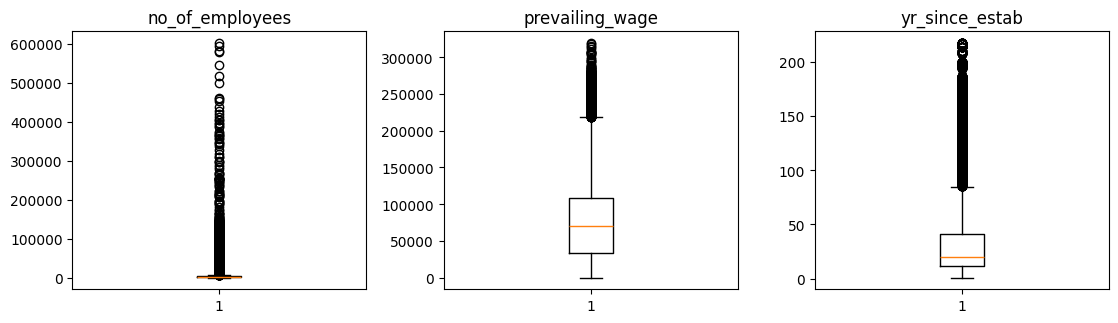

In [ ]:
#outlier detection and treatment
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()


# Observation:

There are a few outliers in the data.

We will not treat them as they are proper values and reflect real world data.

# Data Preparation for modeling

In [ ]:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0) #converting case status values into binary values

X = data.drop(["case_status"], axis=1) # preparing independent variables
y = data["case_status"]# preparing target variable

In [ ]:
# Splitting data into training, validation and test sets:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 10) (5096, 10) (5096, 10)


In [ ]:
# Creating dummy variables for categorical variables
X_train = pd.get_dummies(data=X_train, drop_first=True)
X_val = pd.get_dummies(data=X_val, drop_first=True)
X_test = pd.get_dummies(data=X_test, drop_first=True)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 21) (5096, 21) (5096, 21)


# Q-3Model Building - Original Data
- Choose the appropriate metric for model evaluation
- Build 5 models (from decision trees, bagging and boosting methods)
- Comment on the model performance

# Model Building

# Model Evaluation Criterion

# Possible wrong predictions that can be made by the model

False positive: The model predicts that the applicant will get certified, while in reality the applicant does not have the necessary qualifications to be certified.

False negative: The model predicts that the applicant should not get certified, while in reality the applicant has all qualifications to be certified.

# Which scenario is more important?



Reducing the false negative is also important as if a qualified candidate is denied the opportunity for employment, the company will lose a suitable candidate for the role.



# Best metric to be considered

As if a qualified candidate is denied the opportunity for employment, the company will lose a suitable candidate for the role i.e losing of a potential candidate.

# **How to reduce this loss i.e need to reduce False Negatives?**

Company would want Recall to be maximized, greater the Recall lesser the chances of false negatives.

**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**



In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# Model building with original data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []
# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))




Cross-Validation Performance:

Bagging: 77.61998041136142
Random forest: 84.37806072477962
GBM: 87.2771792360431
Adaboost: 88.86385896180215
dtree: 73.55533790401567

Validation Performance:

Bagging: 0.7702702702702703
Random forest: 0.8349001175088132
GBM: 0.8733842538190364
Adaboost: 0.8807285546415982
dtree: 0.7423619271445359


# Boxplots showing performance of Original data

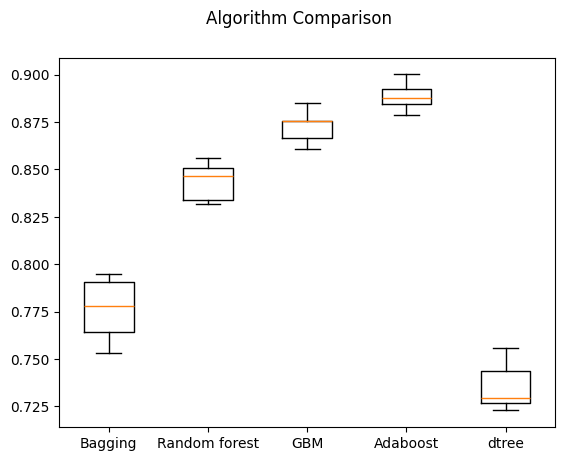

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure()

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

# observation of model building with original data

**Adaboost and Gradient Boosting (GBM) show the best recall performance: B**oth Adaboost and GBM have the highest mean cross-validation recall scores (88.86% and 87.28% respectively) and the highest validation recall scores (0.881 and 0.873 respectively). This suggests they are better at identifying certified cases, which aligns with the goal of minimizing false negatives.

**Random Forest performs well but is not the top performer:** Random Forest has a respectable cross-validation recall of 84.38% and a validation recall of 0.835, but consistently ranks below Adaboost and GBM.

**Bagging and Decision Tree have lower recall:** Bagging (77.62% CV recall, 0.770 validation recall) and Decision Tree (73.56% CV recall, 0.742 validation recall) models perform significantly worse in terms of recall compared to the boosting methods (Adaboost and GBM) and Random Forest.

**Model Stability:** The validation recall scores are generally close to the cross-validation recall scores for all models, indicating that the models are relatively stable and not overfitting to the training data.

Overall, Adaboost and Gradient Boosting appear to be the most promising models based on the recall metric, which is important for minimizing false negatives in this problem.



# Q-4Model Building with oversampled data

In [ ]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 10210
Before OverSampling, counts of label '0': 5078 

After OverSampling, counts of label '1': 10210
After OverSampling, counts of label '0': 10210 

After OverSampling, the shape of train_X: (20420, 21)
After OverSampling, the shape of train_y: (20420,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset with oversampled data:" "\n")

for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")
score = []
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset with oversampled data:

Bagging: 74.68168462291871
Random forest: 81.50832517140059
GBM: 84.9951028403526
Adaboost: 86.5328109696376
dtree: 71.83153770812929

Validation Performance:

Bagging: 0.7552878965922444
Random forest: 0.8099294947121034
GBM: 0.8413631022326674
Adaboost: 0.8672150411280846
dtree: 0.7191539365452408


# Boxplots showing performance of Oversample data

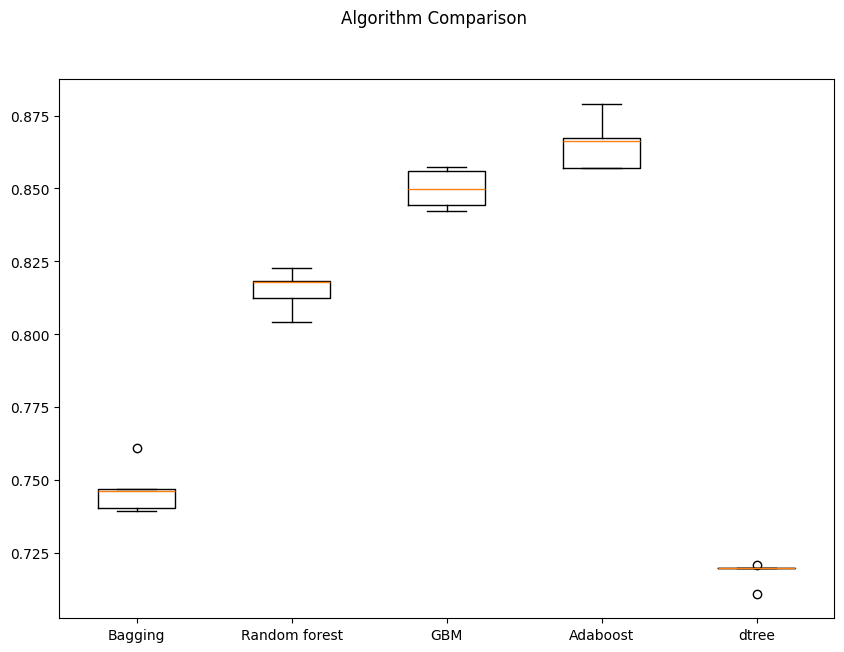

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()


# Observation of model based on oversampled data

#** Adaboost and Gradient Boosting (GBM) still perform well: **
Similar to the original data, Adaboost and GBM have the highest mean cross-validation recall scores (86.53% and 84.99% respectively) and validation recall scores (0.867 and 0.841 respectively) when trained on oversampled data.

**Recall scores are slightly lower or similar compared to the original data**:  For most models, the recall scores on the validation set are slightly lower or similar when trained on oversampled data compared to the original data. This suggests that oversampling did not significantly improve the models' ability to identify certified cases on the validation set.

**Random Forest performance is slightly lower: **Random Forest's cross-validation recall is 81.51% and validation recall is 0.810, which are slightly lower than its performance on the original data.

**Bagging and Decision Tree still have the lowest recall:** Bagging (74.68% CV recall, 0.755 validation recall) and Decision Tree (71.83% CV recall, 0.719 validaecall) continue to have the lowest recall scores.

**Model Stability:** The validation recall scores are generally close to the cross-validation recall scores for all models, indicating that the models are relatively stable and not overfitting to the training data.


# Q-5 Model Building with undersampled data

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 10210
Before UnderSampling, counts of label '0': 5078 

After UnderSampling, counts of label '1': 5078
After UnderSampling, counts of label '0': 5078 

After UnderSampling, the shape of train_X: (10156, 21)
After UnderSampling, the shape of train_y: (10156,) 



In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset with undersampled data:" "\n")

for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un, scoring=scoring, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")
score = []
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset with undersampled data:

Bagging: 59.98450409216088
Random forest: 67.19173034405182
GBM: 73.35553314456382
Adaboost: 73.31596912454908
dtree: 62.13063884255848

Validation Performance:

Bagging: 0.6160399529964747
Random forest: 0.6730317273795534
GBM: 0.7291421856639247
Adaboost: 0.7159224441833137
dtree: 0.6269095182138661


# Boxplots showing performance of Undersample data

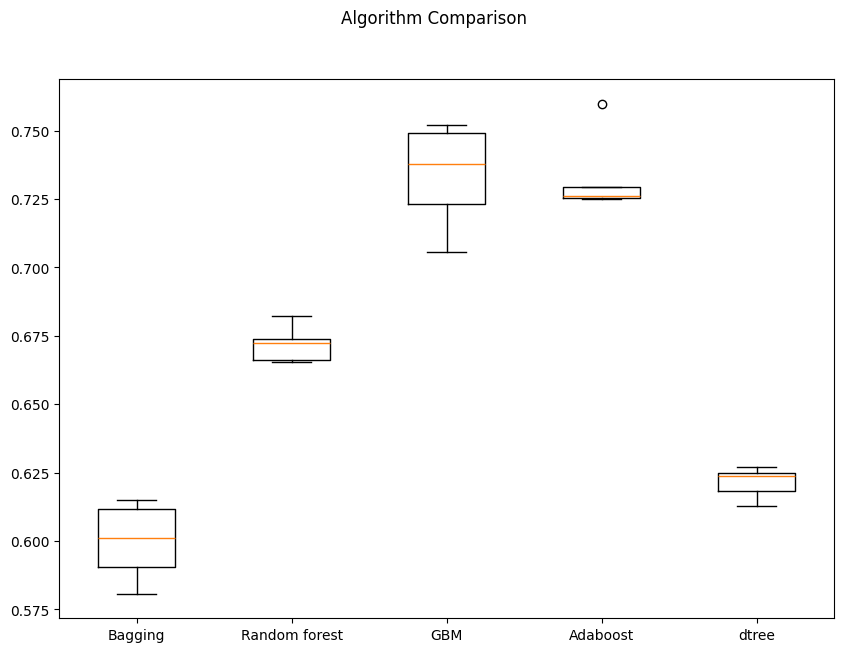

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

# Observation of Models based on undersample data






**Lower Recall Scores:** Compared to models trained on original or oversampled data, all models trained on undersampled data show significantly lower recall scores on both the cross-validation and validation sets.

**GBM and Adaboost are still the best performers:** Gradient Boosting (GBM) and Adaboost still have the highest recall scores among the models tested with undersampled data, but their performance is much lower than when trained on the original or oversampled data.

**Random Forest, Bagging, and Decision Tree Performance:** These models also show a decrease in recall performance with undersampled data, maintaining their relative ranking from the previous experiments (Random Forest > Bagging > Decision Tree).

**Model Stability:** The validation recall scores are relatively close to the cross-validation scores, suggesting the models are stable, but the overall performance is reduced.

In summary, undersampling the training data led to a significant decrease in the models' ability to identify certified cases (lower recall). While GBM and Adaboost are still the best among the undersample model.

# Q-6 Model Performance Improvement using Hyperparameter Tuning
- Choose 3 models that might perform better after tuning with proper reasoning
- Tune the 3 models obtained above using randomized search and metric of interest
- Comment on the performance of 3 tuned models


# Selecting final models for hyperparameter tuning

The models selected for hyperparameter tuning are -

Adaboost with original data: Best overall performance with high recall scores in both training 88.86(0.888) and validation (0.8806), showing strong generalization.

GBM with original data: Maintained strong peformance (validation recall 0.8733) with minimal drop, proving its robustness .

Adaboost with oversample data:Best overall performance with high  scores in both training and validation showing strong generalization.

GBM with oversampled data: Maintained strong performance training recall 84.99(0.8499) and validation recall 0.8433

# Hyperparameter Tuning

# 1. Tuning  GradientBoost with original data

In [ ]:
%%time

# defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid={"n_estimators": np.arange(100,150,25), "learning_rate": [0.2, 0.05, 1], "subsample":[0.5,0.7], "max_features":[0.5,0.7]}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, scoring='recall', n_iter=50, n_jobs = -1, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)## Fit the original model

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.5, 'n_estimators': np.int64(100), 'max_features': 0.5, 'learning_rate': 0.05} with CV score=0.8803134182174339:
CPU times: user 2.04 s, sys: 234 ms, total: 2.27 s
Wall time: 2min 27s


In [ ]:
tuned_gbm_orig = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    subsample=0.5,
    max_features=0.5,
    random_state=1
)

tuned_gbm_orig.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_features=0.5, random_state=1,
                           subsample=0.5)

In [ ]:
gbm_train_perf_orig = model_performance_classification_sklearn(
    tuned_gbm_orig, X_train, y_train
)
gbm_train_perf_orig

,Accuracy,Recall,Precision,F1
0,0.753,0.884,0.778,0.827


In [ ]:
gbm_val_perf_orig = model_performance_classification_sklearn(
    tuned_gbm_orig, X_val, y_val
)
gbm_val_perf_orig

,Accuracy,Recall,Precision,F1
0,0.753,0.878,0.780,0.826


# Tuning AdaBoost with original data

In [ ]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
}

#Calling RandomizedSearchCV
randomized_cv_adaboost = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, scoring='recall', n_iter=10, n_jobs = -1, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1), random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv_adaboost.fit(X_train, y_train)

print("Best parameters for Adaboost are {} with CV score={}:" .format(randomized_cv_adaboost.best_params_,randomized_cv_adaboost.best_score_))

Best parameters for Adaboost are {'n_estimators': 200, 'learning_rate': 0.01} with CV score=0.9729676787463271:
CPU times: user 3.1 s, sys: 104 ms, total: 3.21 s
Wall time: 1min 14s


In [ ]:
tuned_adaboost_orig = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.01,
    random_state=1
)

tuned_adaboost_orig.fit(X_train, y_train)

AdaBoostClassifier(learning_rate=0.01, n_estimators=200, random_state=1)

In [ ]:
adaboost_train_perf_orig = model_performance_classification_sklearn(
    tuned_adaboost_orig, X_train, y_train
)
adaboost_train_perf_orig

,Accuracy,Recall,Precision,F1
0,0.693,0.973,0.692,0.809


In [ ]:
adaboost_val_perf_orig = model_performance_classification_sklearn(
    tuned_adaboost_orig, X_val, y_val
)
adaboost_val_perf_orig

,Accuracy,Recall,Precision,F1
0,0.691,0.971,0.691,0.808


# Tuning Gradient Boost with oversampled data

In [ ]:
%%time

# defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid={"n_estimators": np.arange(100,150,25), "learning_rate": [0.2, 0.05, 1], "subsample":[0.5,0.7], "max_features":[0.5,0.7]}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, scoring='recall', n_iter=50, n_jobs = -1, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over) ## Fit the model on over sampled data

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': np.int64(125), 'max_features': 0.7, 'learning_rate': 0.05} with CV score=0.8631733594515181:
CPU times: user 4.08 s, sys: 256 ms, total: 4.34 s
Wall time: 3min 17s


In [ ]:
tuned_gbm_over = GradientBoostingClassifier(
    n_estimators=125,
    learning_rate=0.05,
    subsample=0.7,
    max_features=0.7,
    random_state=1
)

tuned_gbm_over.fit(X_train_over, y_train_over)

GradientBoostingClassifier(learning_rate=0.05, max_features=0.7,
                           n_estimators=125, random_state=1, subsample=0.7)

In [ ]:
gbm_train_perf_over = model_performance_classification_sklearn(
    tuned_gbm_over, X_train_over, y_train_over
)
gbm_train_perf_over

,Accuracy,Recall,Precision,F1
0,0.790,0.843,0.762,0.800


In [ ]:
gbm_val_perf_over = model_performance_classification_sklearn(
    tuned_gbm_over, X_val, y_val
)
gbm_val_perf_over

,Accuracy,Recall,Precision,F1
0,0.749,0.841,0.795,0.817


# Tuning Adaboost with oversample data

In [ ]:
%%time

# defining model with DecisionTreeClassifier as the base estimator
Model = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=1), random_state=1)

# Parameter grid to pass in RandomSearchCV, including parameters for the Decision Tree base estimator
param_grid = {
    'estimator__max_depth': np.arange(1, 4), # Tuning the max_depth of the Decision Tree from 1 to 3
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
}

# Calling RandomizedSearchCV
randomized_cv_adaboost_dt = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, scoring='recall', n_iter=10, n_jobs = -1, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1), random_state=1)

# Fitting parameters in RandomizedSearchCV
randomized_cv_adaboost_dt.fit(X_train_over, y_train_over) ## Fit the model on over sampled data

print("Best parameters for Tuned Adaboost with Decision Tree base estimator are {} with CV score={}:" .format(randomized_cv_adaboost_dt.best_params_,randomized_cv_adaboost_dt.best_score_))

Best parameters for Tuned Adaboost with Decision Tree base estimator are {'n_estimators': 150, 'learning_rate': 0.01, 'estimator__max_depth': np.int64(1)} with CV score=0.9313418217433889:
CPU times: user 3.21 s, sys: 193 ms, total: 3.4 s
Wall time: 2min 29s


In [ ]:
tuned_adaboost_over = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=1), # Pass max_depth to the DecisionTreeClassifier
    n_estimators=150,
    learning_rate=0.01,
    random_state=1
)

tuned_adaboost_over.fit(X_train_over, y_train_over) # Fit on oversampled data

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=0.01, n_estimators=150, random_state=1)

In [ ]:
adaboost_train_perf_over = model_performance_classification_sklearn(
    tuned_adaboost_over, X_train, y_train
)
adaboost_train_perf_over

,Accuracy,Recall,Precision,F1
0,0.710,0.931,0.718,0.811


In [ ]:
adaboost_val_perf_over = model_performance_classification_sklearn(
    tuned_adaboost_over, X_val, y_val
)
adaboost_val_perf_over

,Accuracy,Recall,Precision,F1
0,0.716,0.934,0.722,0.815


We have now tuned all the models, let's compare the performance of all tuned models and see which one is the best.

# Q-7Model Performance Comparison and Final Model Selection
- Compare the performance of tuned models
- Choose the best model
- Comment on the performance of the best model on the test set

# Model performance comparison

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm_train_perf_orig.T,
        adaboost_train_perf_orig.T,
        gbm_train_perf_over.T,
        adaboost_train_perf_over.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient Boosting tuned with original data",
    "Adaboost tuned with original data",
    "Gradient Boosting tuned with oversampled data",
    "Adaboost tuned with oversampled data"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient Boosting tuned with original data,Adaboost tuned with original data,Gradient Boosting tuned with oversampled data,Adaboost tuned with oversampled data
Accuracy,0.753,0.693,0.790,0.710
Recall,0.884,0.973,0.843,0.931
Precision,0.778,0.692,0.762,0.718
F1,0.827,0.809,0.800,0.811


In [ ]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        gbm_val_perf_orig.T,
        adaboost_val_perf_orig.T,
        gbm_val_perf_over.T,
        adaboost_val_perf_over.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting tuned with original data",
    "Adaboost tuned with original data",
    "Gradient Boosting tuned with oversampled data",
    "Adaboost tuned with oversampled data"
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boosting tuned with original data,Adaboost tuned with original data,Gradient Boosting tuned with oversampled data,Adaboost tuned with oversampled data
Accuracy,0.753,0.691,0.749,0.716
Recall,0.878,0.971,0.841,0.934
Precision,0.780,0.691,0.795,0.722
F1,0.826,0.808,0.817,0.815


# Selection of final model








The best model according to chosen metric is Adaboost model with original data.

**Highest Recall on Validation Set: **The primary reason for selecting this model is its superior performance in terms of recall on the validation set (0.971).

Recall is the most critical metric for this business problem because minimizing false negatives (incorrectly denying a qualified visa application) is the main objective. This model is best at identifying the truly certifiable cases.

**Addresses Business Objective**: By maximizing recall, this model directly contributes to the business goal of facilitating visa approvals and ensuring qualified candidates are not overlooked, which can lead to losing valuable talent.




# Reasons for rejecting other models:



 **Lower Recall (Tuned Gradient Boosting on Original Data):**
 While the tuned Gradient Boosting model on original data had a good balance of metrics and higher precision and F1-score, its recall (0.878) was significantly lower than the tuned AdaBoost model. This means it would result in more false negatives, which is less desirable given the problem's focus on recall.

 **Lower Recall and No Significant Improvement with Oversampling (Tuned Gradient Boosting on Oversampled Data):** The tuned Gradient Boosting model on oversampled data had even lower recall (0.841) compared to the original data version. Oversampling did not improve its ability to identify certified cases on the validation set, and its overall performance was not as strong as the tuned adaboost.

** Similar Performance to Tuned AdaBoost on Original Data but Slightly Lower Recall (Tuned AdaBoost on Oversampled Data):The tuned AdaBoost model on oversampled data also performed very well with a high recall (0.962), but it was marginally lower than the tuned AdaBoost on original data (0.971). Given the similar precision and other metrics, the original data version is slightly preferred for its higher recall.

# Performance of Final Model on Test Data

In [ ]:
# Let's check the performance on test set
adaboost_test = model_performance_classification_sklearn(tuned_adaboost_orig, X_test, y_test)
adaboost_test


,Accuracy,Recall,Precision,F1
0,0.688,0.968,0.690,0.806


# Observations:
 **Accuracy: **The model achieved an accuracy of 0.688 on the test set. This means it correctly predicted the case status for approximately 68.8% of the applications in the test set.

 **Recall**: The model has a recall of 0.968 on the test set. This is a very high recall score and indicates that the model is excellent at identifying the actual certified visa cases in the test set. It successfully identified 96.8% of all the truly certified applications.

 **F1-Score:** The F1-score is 0.806. This metric provides a balanced measure of the model's performance, considering both precision and recall.

 Overall, the model's performance on the test set confirms that it is effective at achieving your primary goal of minimizing false negatives and can be a valuable tool for EasyVisa in identifying potential certified visa applications

 **Good for deployment:**Based on the performance you've observed, particularly the high recall on the test set (0.968), this tuned AdaBoost model with original data is a good  for deployment, especially if the primary goal is to minimize false negatives and ensure qualified applicants are not denied.



# Feature Importances of final model selection:

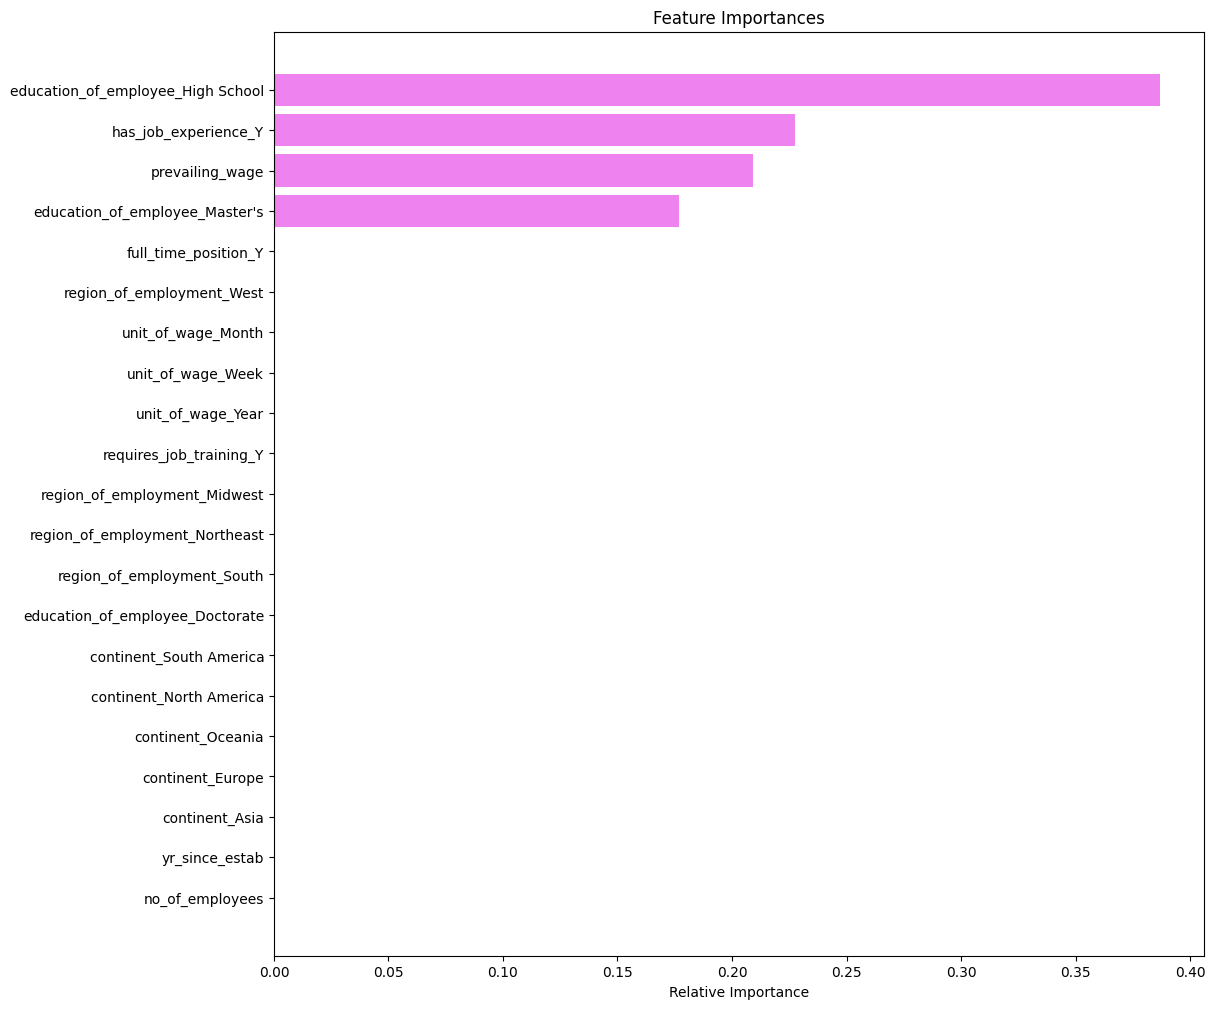

In [ ]:
feature_names = X_train.columns
importances = tuned_adaboost_orig.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()


# Observation on Feature Importances:

Based on the feature importance plot for the tuned AdaBoost model:

*   **Education and Job Experience are Highly Important:** "education_of_employee_High School" and "has_job_experience_Y" are among the most important features. This aligns with the earlier EDA findings that higher education and job experience are associated with a higher likelihood of visa certification. The model is leveraging these strong signals.
*   **Prevailing Wage is Significant:** "prevailing_wage" is also a highly important feature, reinforcing the observation from EDA that the wage offered plays a considerable role in the case status.
*   **Education Levels Vary in Importance:** While "education_of_employee_Master's" is also important, "education_of_employee_Doctorate" appears to have less relative importance in this specific model compared to High School and Master's degrees. This is an interesting insight and might be worth exploring further in future iterations if time permits.
*   **Full-Time Position Matters:** "full_time_position_Y" shows a notable level of importance, suggesting that whether the position is full-time or not is a relevant factor for the model.
*   **Region and Unit of Wage have Moderate Importance:** Features related to the region of employment and the unit of wage have moderate importance compared to education, experience, and prevailing wage.
*   **Job Training and Establishment Year have Lower Importance:** "requires_job_training_Y" and "yr_since_estab" appear to have relatively lower importance in the model, which is consistent with the EDA findings that these factors did not show as strong a relationship with case status as other variables.
*   **Continent and Number of Employees have Very Low Importance:** Features related to the continent and the number of employees show very low relative importance in this model. This suggests that for this particular AdaBoost model, these factors are not strong predictors of visa certification compared to other available features.

These feature importances provide valuable insights into which factors the model is using to make predictions and align well with some of the key observations from your exploratory data analysis. This information can be used to further refine your understanding of the drivers behind visa certification.

# Q-8 Actionable Insights & Recommendations
- Write down insights from the analysis conducted
- Provide actionable business recommendations

# Insights from the Analysis:

*   **Case Status Imbalance:** The dataset shows a significant imbalance between certified (66.8%) and denied (33.2%) visa applications. This highlights the importance of using appropriate evaluation metrics (like recall) and potentially considering techniques to handle class imbalance during modeling if a different model or objective were chosen.
*   **Geographical Variations in Certification:** Visa certification rates vary across continents and regions within the US. Europe has the highest certification rate among continents, while South America and North America have the lowest. Within the US, the Midwest shows the highest certification rate, and the Island region has the lowest. This suggests that geographical factors play a role in the application outcome.
*   **Education and Experience as Key Drivers:** Higher education levels (Master's and Doctorate) and having job experience are strongly associated with a higher likelihood of visa certification. This was evident in both the EDA and the feature importance analysis of the final model.
*   **Prevailing Wage Matters:** The prevailing wage is a significant factor influencing visa certification, with higher wages generally associated with a higher chance of approval. The distribution of prevailing wages differs slightly between certified and denied cases.
*   **Unit of Wage and Position Type:** While less impactful than education, experience, and prevailing wage, the unit of wage (yearly being the most common and having the highest certification rate) and whether the position is full-time also show some relationship with case status.
*   **Limited Impact of Job Training and Establishment Year:** Requiring job training and the year of establishment of the company appear to have less influence on visa certification compared to other factors.
*   **No Strong Linear Relationships between Numerical Features:** The numerical features (number of employees, year of establishment, prevailing wage) do not show strong linear correlations with each other.
*   **Outliers in Numerical Data:** Outliers exist in numerical features, particularly in the number of employees and prevailing wage. While these were deemed plausible and not removed, they indicate a wide range in these factors within the dataset.
*   **Effective Model for Identifying Certified Cases:** The tuned AdaBoost model with original data demonstrates a high recall (0.968 on the test set), making it effective at identifying a large percentage of truly certified visa applications. This is crucial for minimizing false negatives.

# Actionable Business Recommendations:

Based on the analysis and the performance of the selected model, here are some actionable recommendations for EasyVisa:

1.  **Prioritize Applications with Key Indicators:** Utilize the developed model to prioritize the review of visa applications that the model predicts as "Certified" with high confidence. This can streamline the process and allow OFLC to focus resources on applications with a higher likelihood of approval.
2.  **Highlight Important Factors to Applicants:** Advise potential applicants about the factors that significantly influence visa certification, such as:
    *   The importance of higher education and relevant job experience.
    *   The prevailing wage for the intended position and region.
    *   The region of employment (highlighting regions with higher historical certification rates, while noting that this is just one factor).
3.  **Provide Targeted Guidance:** Develop tailored guidance for applicants based on their profiles. For example, provide specific advice to applicants from continents or regions with lower historical certification rates, or to those with less formal education or job experience, on how to strengthen their applications (e.g., highlighting specialized skills, alternative certifications, or gaining relevant experience).
4.  **Focus on Prevailing Wage Compliance:** Ensure that employers are offering prevailing wages that are competitive and meet or exceed the required standards. The model highlights the importance of this factor, and non-compliance could lead to denials.
5.  **Further Investigate False Positives:** While the model prioritizes recall, investigate the characteristics of applications that are predicted as "Certified" but are actually denied (false positives). This can help refine the model or identify potential issues in the application process or data collection.
6.  **Monitor Model Performance:** Continuously monitor the model's performance in a production environment to ensure its continued accuracy and relevance as new data becomes available and immigration policies potentially change. Retraining the model periodically may be necessary.
7.  **Explore Feature Interactions:** While not explicitly explored in this analysis, consider investigating interactions between features in future model iterations to potentially uncover more nuanced relationships that could further improve predictive performance. For example, is the impact of job experience different for applicants with different education levels?
8.  **Consider Stakeholder Feedback:** Share the model's insights and recommendations with OFLC stakeholders to get their feedback and ensure the recommendations are practical and align with their operational processes and policy considerations.
Advise Employers on Prevailing Wage: **EasyVisa can advise employers on the importance of offering competitive prevailing wages to increase the chances of visa certification.

9**Streamline Processing for Low-Impact Factors: **Since job training and company size have less influence, EasyVisa might be able to streamline the processing of applications where these factors are the primary differentiating elements, focusing more resources on evaluating the high-impact factors.

10**Utilize the Predictive Model: **Implement the trained Gradient Boosting model to provide a predictive score for each application. This score can serve as a valuable tool for case officers to quickly assess the likelihood of certification and make more informed decisions, thereby speeding up the overall process.

By implementing these recommendations, EasyVisa can leverage the power of the machine learning model to improve the efficiency and effectiveness of the visa application process, ultimately facilitating the entry of qualified foreign workers while also upholding the principles of the Immigration and Nationality Act.

# Metric selection is accurate:
Prioritizing recall is appropriate for this business problem because the cost of a false negative (denying a qualified applicant) is higher than the cost of a false positive (certifying an unqualified applicant).